# Experimento SADI + Silhouette Score

Detecção de comunidades via Simulated Annealing com Dissimilarity Index (SADI),
substituindo a modularity Q pelo Silhouette Score.

**Referência:** Liu & Liu, Physica A 389 (2010) 2300–2309.

In [1]:
import sys, os, random
sys.path.insert(0, os.path.abspath('.'))

from modules.data_loader import (
    load_karate_club, load_gml, load_football, load_polbooks,
    load_dolphins, load_lesmis,
    generate_ad_hoc_network, generate_gaussian_network,
    evaluate_ari
)
from modules.markov import build_dissimilarity
from modules.sadi import sadi_algorithm
from modules.visualization import (
    plot_dissimilarity_heatmap, plot_communities,
    plot_comparison, plot_adhoc_experiment, match_labels,
    plot_silhouette_history, plot_cooling_comparison,
    plot_n_communities_stats
)

import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

COOLING_SCHEDULES = ['geometric', 'linear', 'logarithmic']
SADI_PARAMS = dict(T_max=3.0, T_min=0.01, alpha=0.9, R=20, N_min=2, N_max=20)
random.seed(42)

IMG_DIR = os.path.join(os.path.abspath('.'), 'images')
DATA_DIR = os.path.join(os.path.abspath('.'), 'data')

for ds in ['karate', 'dolphins', 'polbooks', 'lesmis', 'football', 'adhoc', 'gaussian']:
    os.makedirs(os.path.join(IMG_DIR, ds), exist_ok=True)

# all_results[dataset]['sil'|'mod'][schedule] = {score, ari, n_comm}
all_results = {}

def run_both_objectives(G, Delta, true_labels, ds_name, has_gt=True):
    """Roda sil e mod para os 3 cooling schedules e retorna (sil_results, mod_results)."""
    sil_res, mod_res = {}, {}
    all_results[ds_name] = {'sil': {}, 'mod': {}}
    for schedule in COOLING_SCHEDULES:
        # Silhouette
        lbl_s, ctr_s, sil, hist_s = sadi_algorithm(
            G, Delta, cooling=schedule, objective='silhouette', **SADI_PARAMS)
        ari_s = evaluate_ari(true_labels, lbl_s) if has_gt else None
        sil_res[schedule] = dict(labels=lbl_s, centers=ctr_s, score=sil, ari=ari_s, history=hist_s)
        all_results[ds_name]['sil'][schedule] = dict(score=sil, ari=ari_s, n_comm=len(ctr_s))
        sil_str = f"Sil: {sil:.4f}"
        ari_str = f" | ARI: {ari_s:.4f}" if ari_s is not None else ""
        print(f"  [sil] {schedule:12s} | Comunidades: {len(ctr_s)} | {sil_str}{ari_str}")

        # Modularity Q
        lbl_m, ctr_m, Q, hist_m = sadi_algorithm(
            G, Delta, cooling=schedule, objective='modularity', **SADI_PARAMS)
        ari_m = evaluate_ari(true_labels, lbl_m) if has_gt else None
        mod_res[schedule] = dict(labels=lbl_m, centers=ctr_m, score=Q, ari=ari_m, history=hist_m)
        all_results[ds_name]['mod'][schedule] = dict(score=Q, ari=ari_m, n_comm=len(ctr_m))
        q_str = f"Q: {Q:.4f}"
        ari_str = f" | ARI: {ari_m:.4f}" if ari_m is not None else ""
        print(f"  [mod] {schedule:12s} | Comunidades: {len(ctr_m)} | {q_str}{ari_str}")

    best_sil_s = max(COOLING_SCHEDULES, key=lambda s: sil_res[s]['score'])
    best_mod_s = max(COOLING_SCHEDULES, key=lambda s: mod_res[s]['score'])
    print(f"\n  → Melhor Silhouette: {best_sil_s} ({sil_res[best_sil_s]['score']:.4f})")
    print(f"  → Melhor Modularity: {best_mod_s} ({mod_res[best_mod_s]['score']:.4f})")
    return sil_res, mod_res, best_sil_s, best_mod_s


## 1. Karate Club (Zachary) — Comparação de Funções de Resfriamento

Rede social clássica com 34 nós e estrutura de 2 comunidades conhecida.
Executa o SADI com três esquemas de resfriamento e compara os resultados.

In [2]:
G_karate, true_labels_karate = load_karate_club()
print(f"Nós: {G_karate.number_of_nodes()}, Arestas: {G_karate.number_of_edges()}")

Delta_karate, _, _ = build_dissimilarity(G_karate)
print("Matriz de dissimilaridade calculada.")

Nós: 34, Arestas: 78
Matriz de dissimilaridade calculada.


In [3]:
random.seed(42)
print("=== Karate Club ===")
karate_sil, karate_mod, karate_best_sil_s, karate_best_mod_s = run_both_objectives(
    G_karate, Delta_karate, true_labels_karate, 'karate', has_gt=True)
karate_sil_best = karate_sil[karate_best_sil_s]
karate_mod_best = karate_mod[karate_best_mod_s]


=== Karate Club ===
  [sil] geometric    | Comunidades: 3 | Sil: 0.6615 | ARI: 0.6841
  [mod] geometric    | Comunidades: 3 | Q: 0.4345 | ARI: 0.6841
  [sil] linear       | Comunidades: 3 | Sil: 0.6615 | ARI: 0.6841
  [mod] linear       | Comunidades: 3 | Q: 0.4345 | ARI: 0.6841
  [sil] logarithmic  | Comunidades: 3 | Sil: 0.6615 | ARI: 0.6841
  [mod] logarithmic  | Comunidades: 3 | Q: 0.4345 | ARI: 0.6841

  → Melhor Silhouette: geometric (0.6615)
  → Melhor Modularity: geometric (0.4345)


### 1.1 Detecção de comunidades vs. ground truth — por função de resfriamento

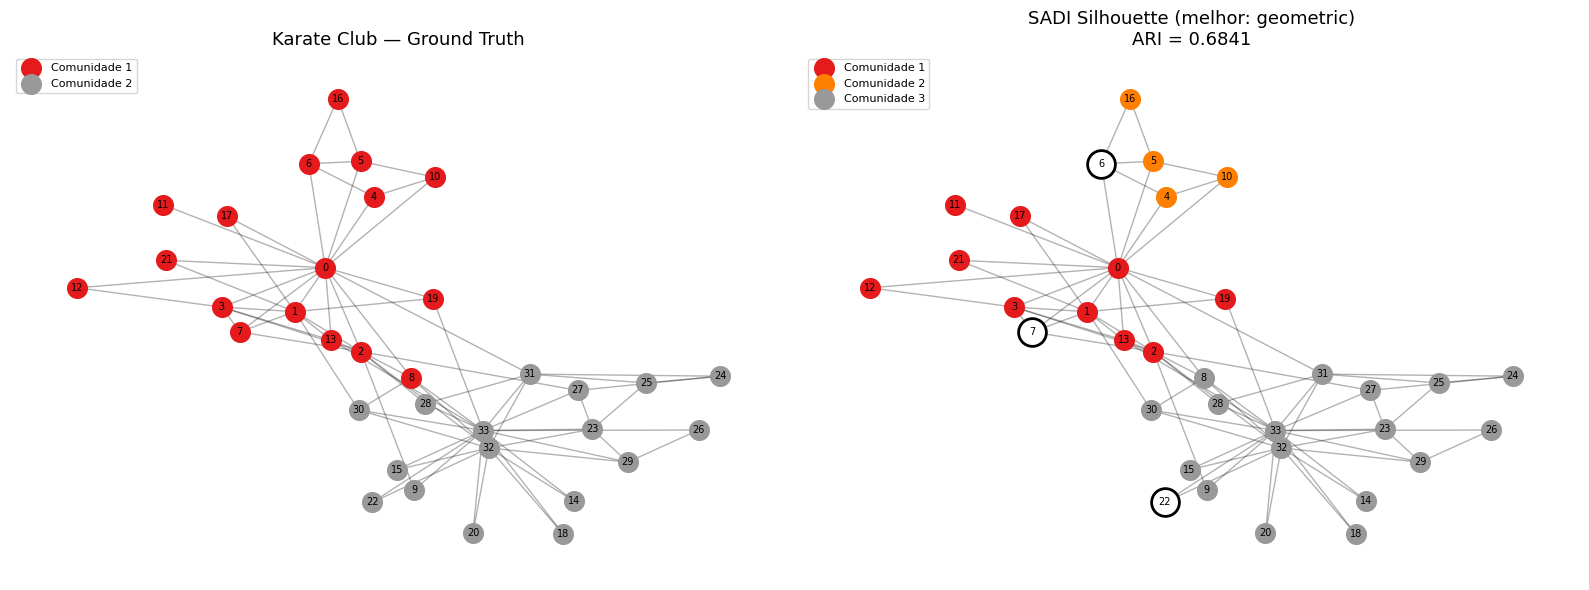

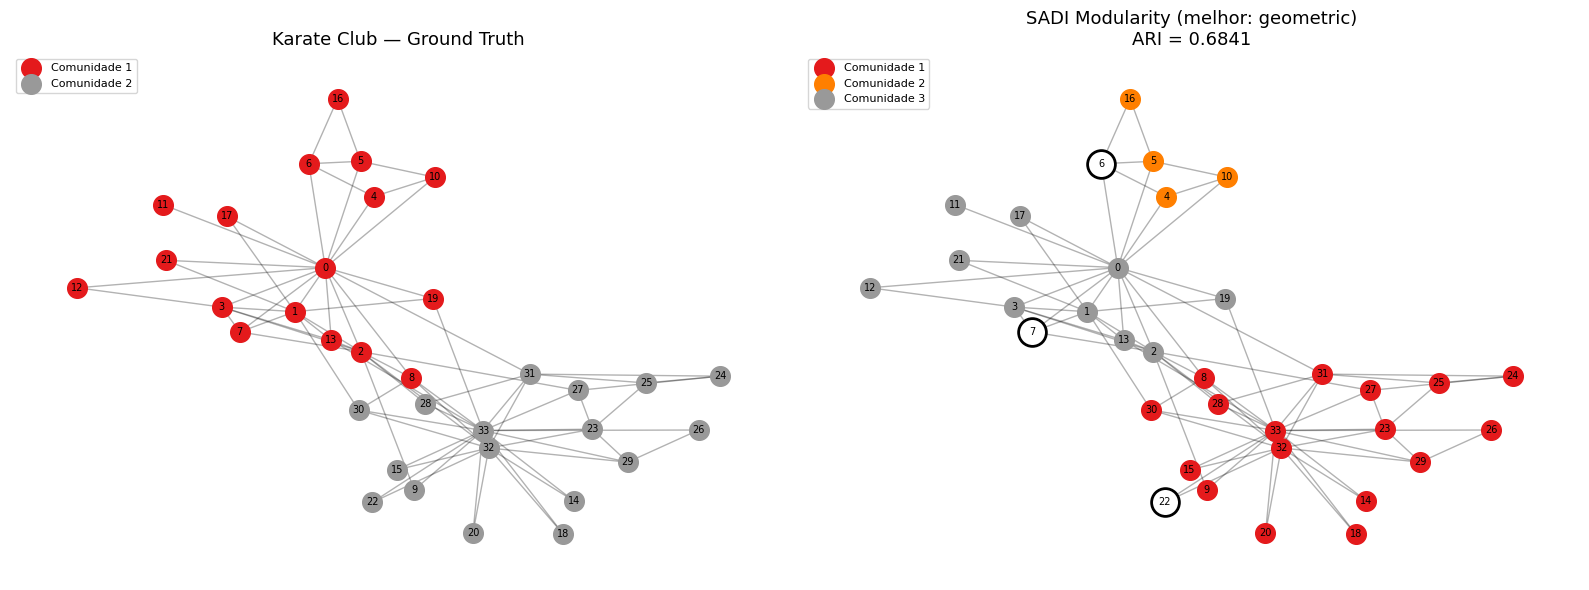

In [4]:
plot_comparison(
    G_karate, true_labels_karate, karate_sil_best['labels'], karate_sil_best['centers'],
    title_true="Karate Club — Ground Truth",
    title_pred=f"SADI Silhouette (melhor: {karate_best_sil_s})",
    ari=karate_sil_best['ari'],
    save_path=os.path.join(IMG_DIR, 'karate', "karate_comparacao_sil_best.png")
)
plot_comparison(
    G_karate, true_labels_karate, karate_mod_best['labels'], karate_mod_best['centers'],
    title_true="Karate Club — Ground Truth",
    title_pred=f"SADI Modularity (melhor: {karate_best_mod_s})",
    ari=karate_mod_best['ari'],
    save_path=os.path.join(IMG_DIR, 'karate', "karate_comparacao_mod_best.png")
)


### 1.2 Evolução do Silhouette Score — por função de resfriamento

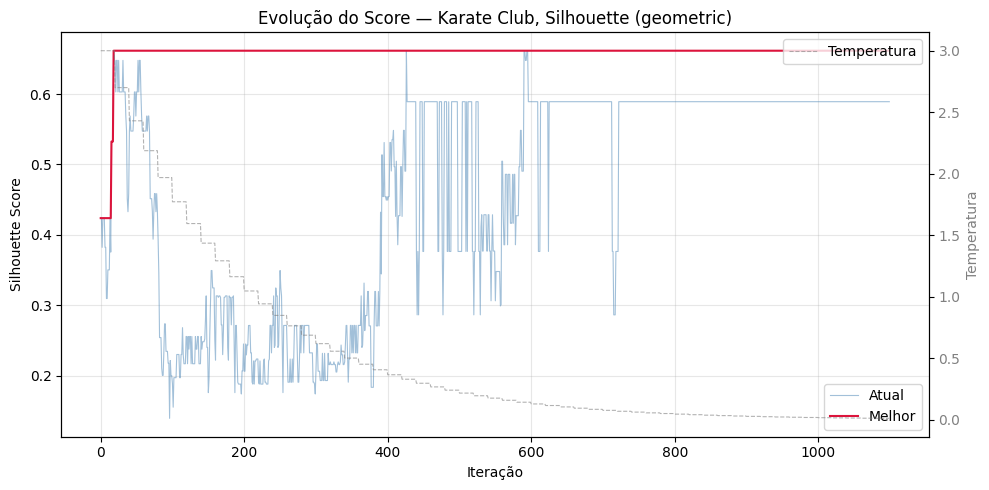

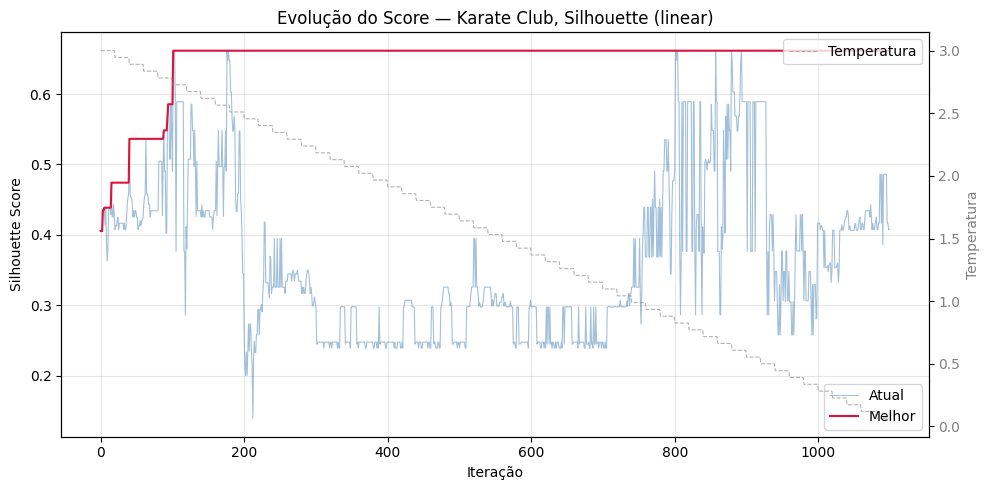

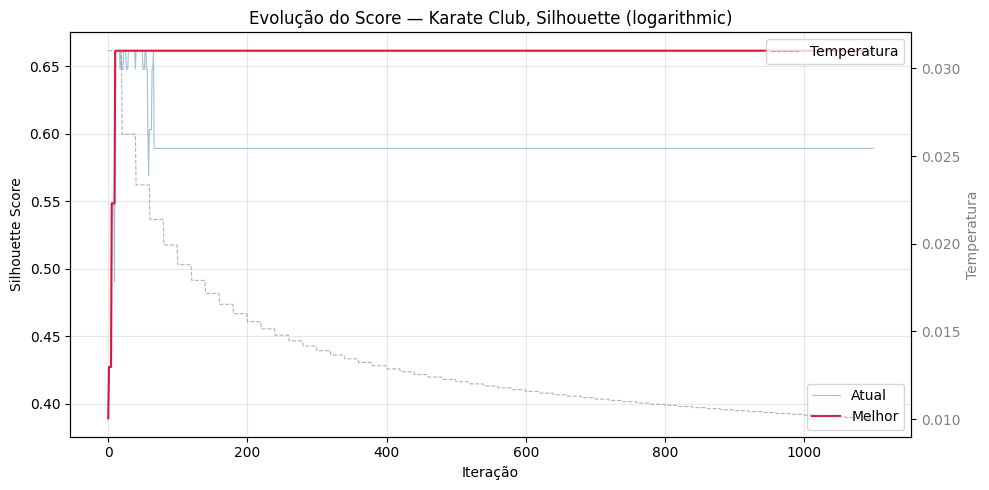

In [5]:
for schedule in COOLING_SCHEDULES:
    plot_silhouette_history(
        karate_sil[schedule]['history'],
        title=f"Evolução do Score — Karate Club, Silhouette ({schedule})",
        save_path=os.path.join(IMG_DIR, 'karate', f"karate_sil_history_{schedule}.png")
    )


### 1.3 Estatísticas de visita por Nº de comunidades — Karate Club

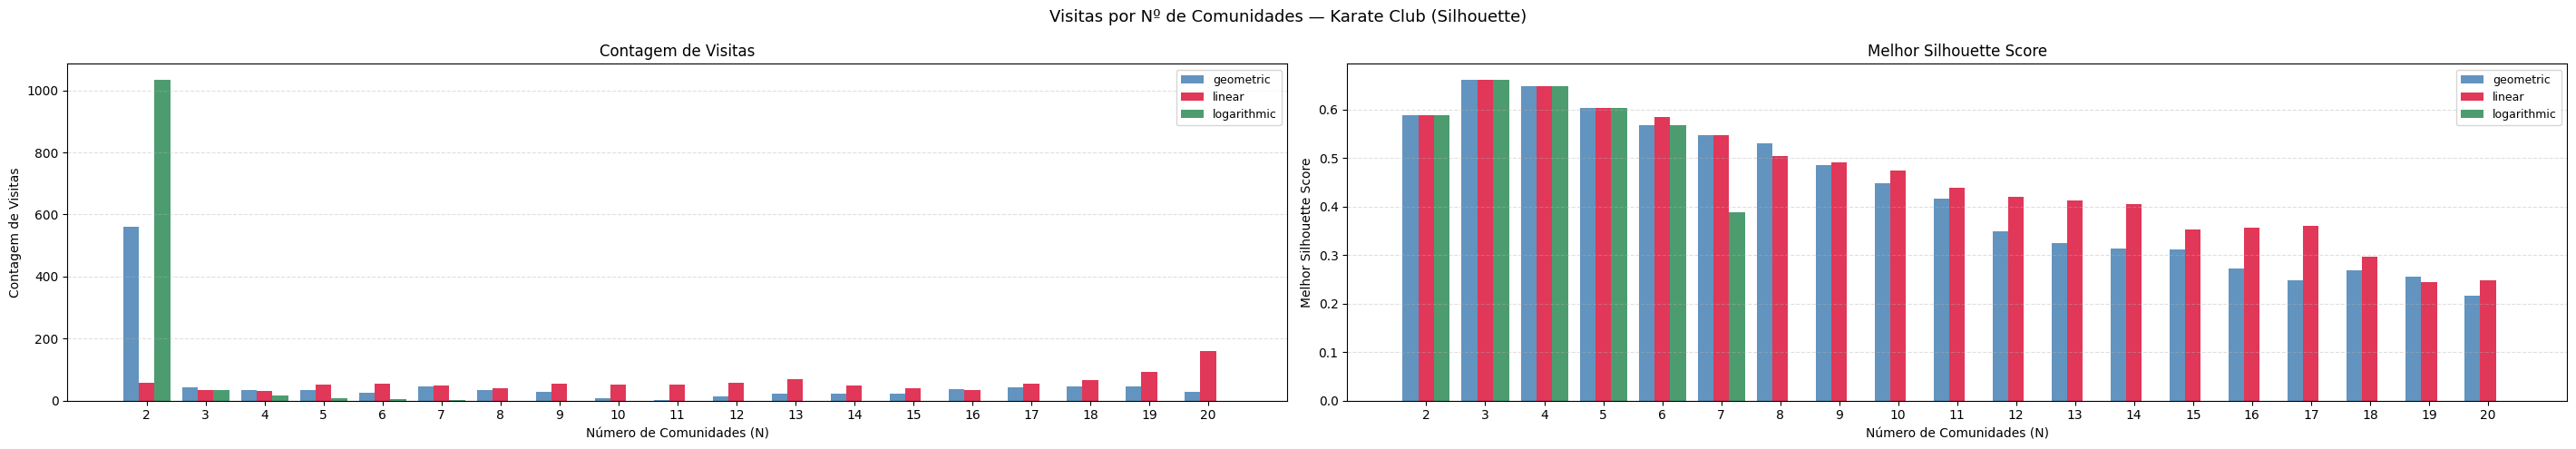

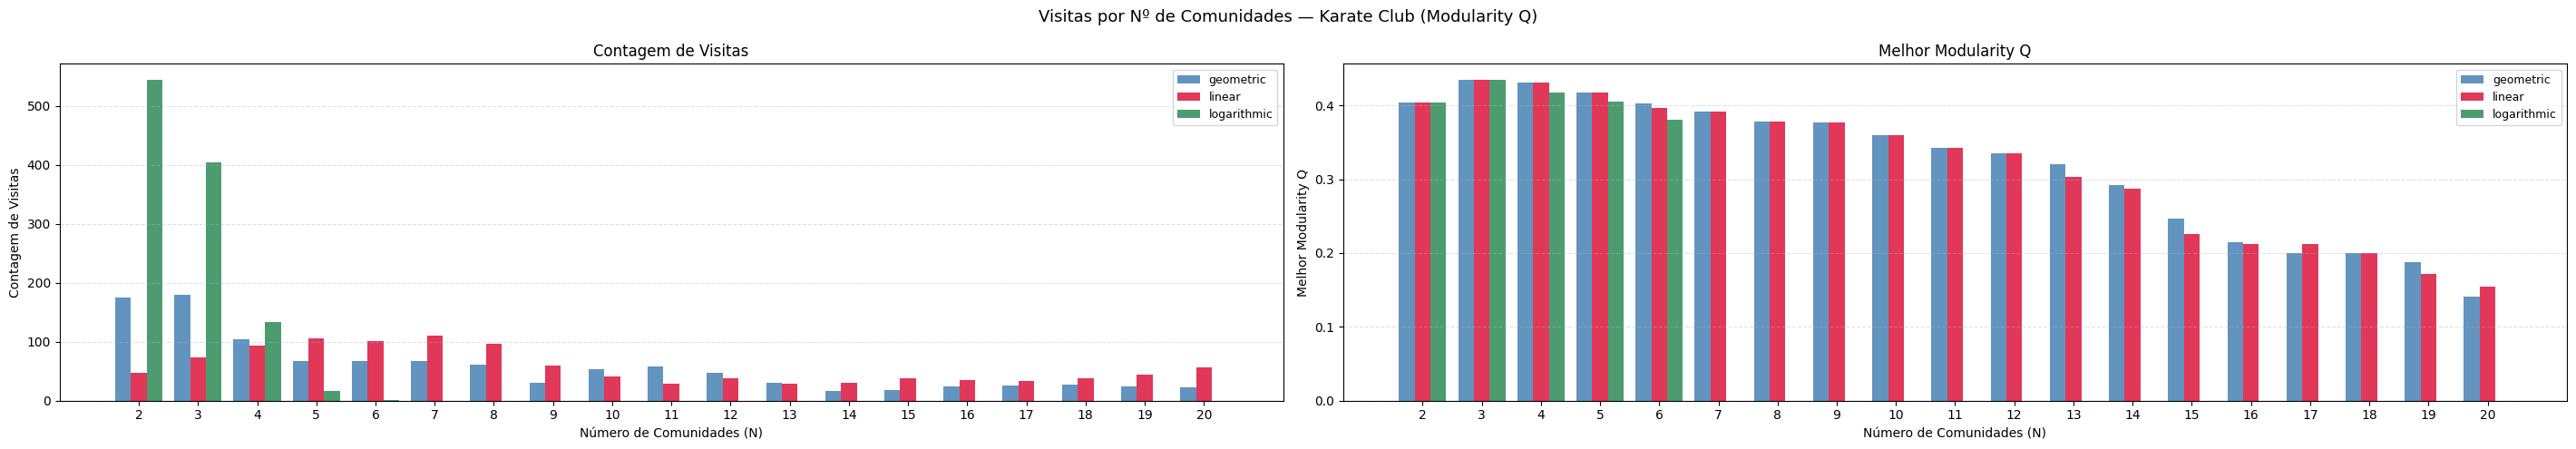

In [6]:
plot_n_communities_stats(
    histories=[karate_sil[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Karate Club (Silhouette)",
    score_label="Melhor Silhouette Score",
    save_path=os.path.join(IMG_DIR, 'karate', "karate_n_communities_sil.png")
)
plot_n_communities_stats(
    histories=[karate_mod[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Karate Club (Modularity Q)",
    score_label="Melhor Modularity Q",
    save_path=os.path.join(IMG_DIR, 'karate', "karate_n_communities_mod.png")
)


## 3. Dolphins — Comparação de Funções de Resfriamento

Rede social de golfinhos (Lusseau et al.) com 62 nós. Sem ground truth oficial — avaliamos apenas o Silhouette Score.

In [7]:
G_dolphins, true_labels_dolphins = load_dolphins(os.path.join(DATA_DIR, 'dolphins.zip'))
print(f"Nós: {G_dolphins.number_of_nodes()}, Arestas: {G_dolphins.number_of_edges()}")

Delta_dolphins, _, _ = build_dissimilarity(G_dolphins)
print("Matriz de dissimilaridade calculada.")

Nós: 62, Arestas: 159
Matriz de dissimilaridade calculada.


In [8]:
random.seed(42)
print("=== Dolphins ===")
dolphins_sil, dolphins_mod, dolphins_best_sil_s, dolphins_best_mod_s = run_both_objectives(
    G_dolphins, Delta_dolphins, None, 'dolphins', has_gt=False)
dolphins_sil_best = dolphins_sil[dolphins_best_sil_s]
dolphins_mod_best = dolphins_mod[dolphins_best_mod_s]


=== Dolphins ===
  [sil] geometric    | Comunidades: 2 | Sil: 0.7300
  [mod] geometric    | Comunidades: 6 | Q: 0.4864
  [sil] linear       | Comunidades: 2 | Sil: 0.7300
  [mod] linear       | Comunidades: 6 | Q: 0.4864
  [sil] logarithmic  | Comunidades: 2 | Sil: 0.7300
  [mod] logarithmic  | Comunidades: 6 | Q: 0.4864

  → Melhor Silhouette: geometric (0.7300)
  → Melhor Modularity: geometric (0.4864)


### 3.1 Comunidades detectadas — por função de resfriamento

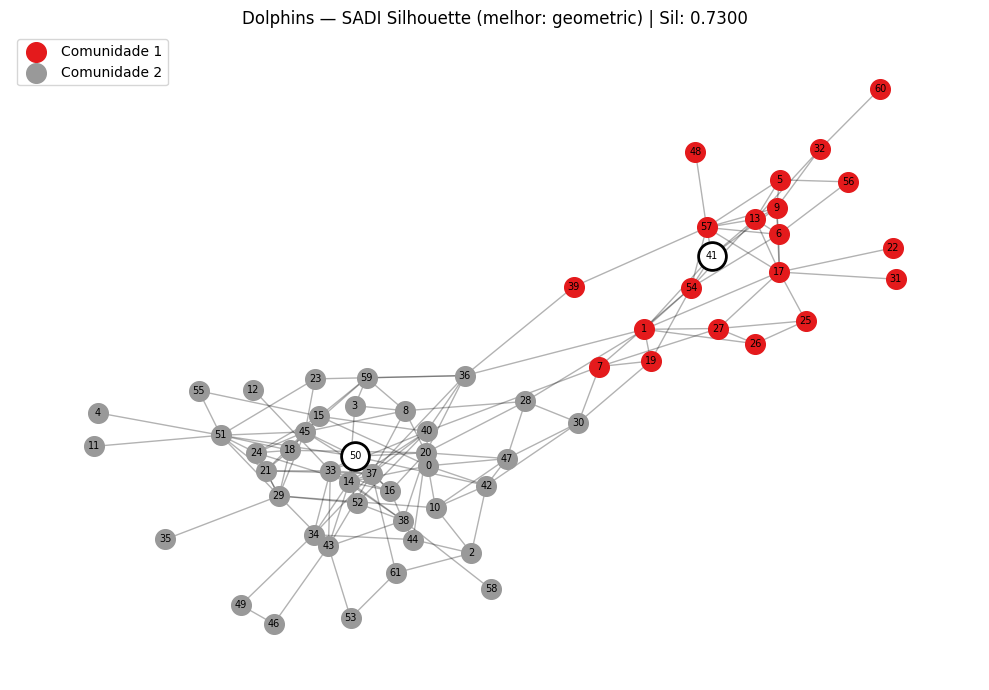

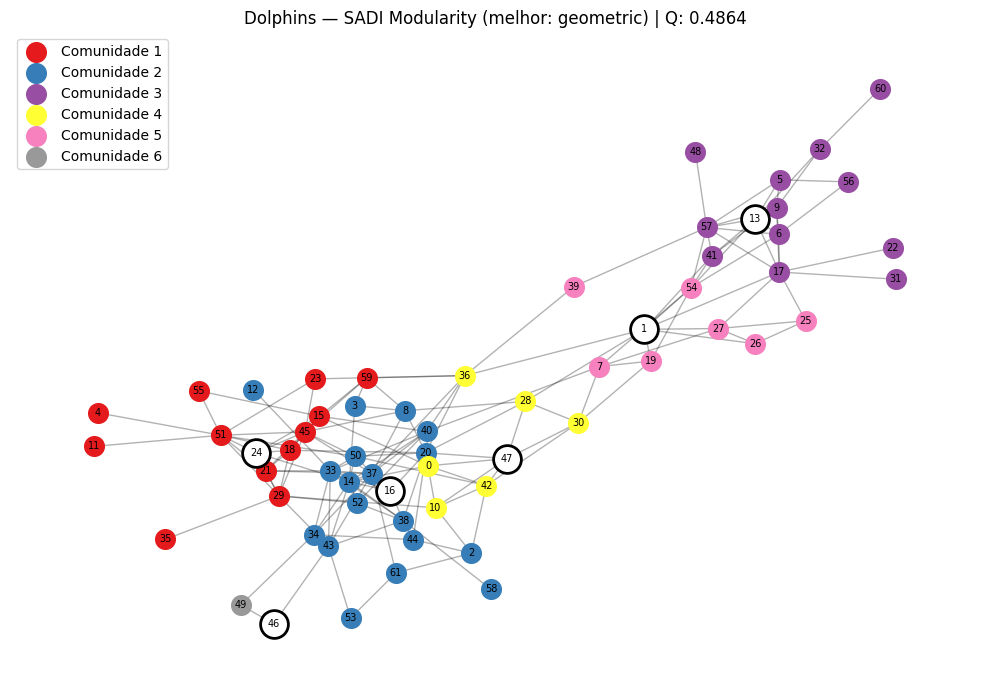

In [9]:
plot_communities(
    G_dolphins, dolphins_sil_best['labels'], dolphins_sil_best['centers'],
    title=f"Dolphins — SADI Silhouette (melhor: {dolphins_best_sil_s}) | Sil: {dolphins_sil_best['score']:.4f}",
    save_path=os.path.join(IMG_DIR, 'dolphins', "dolphins_sil_best.png")
)
plot_communities(
    G_dolphins, dolphins_mod_best['labels'], dolphins_mod_best['centers'],
    title=f"Dolphins — SADI Modularity (melhor: {dolphins_best_mod_s}) | Q: {dolphins_mod_best['score']:.4f}",
    save_path=os.path.join(IMG_DIR, 'dolphins', "dolphins_mod_best.png")
)


### 3.2 Evolução do Silhouette Score — por função de resfriamento

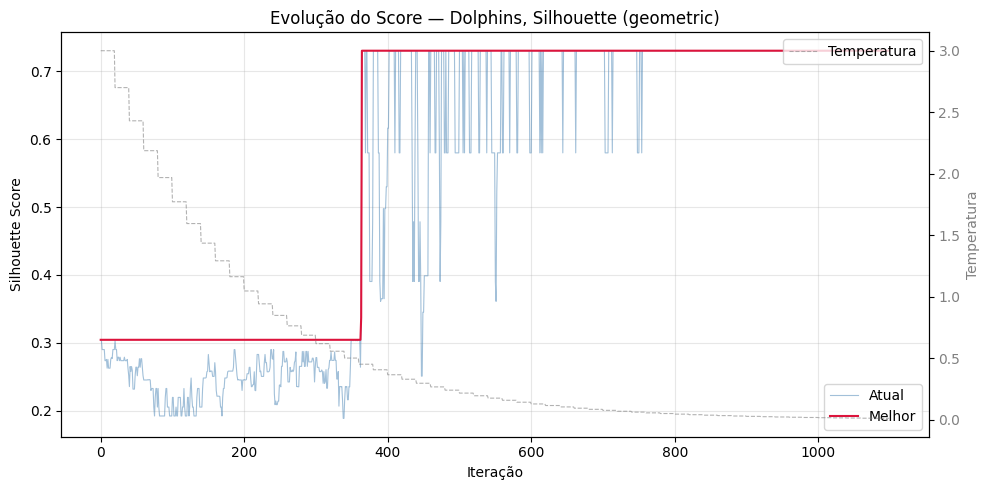

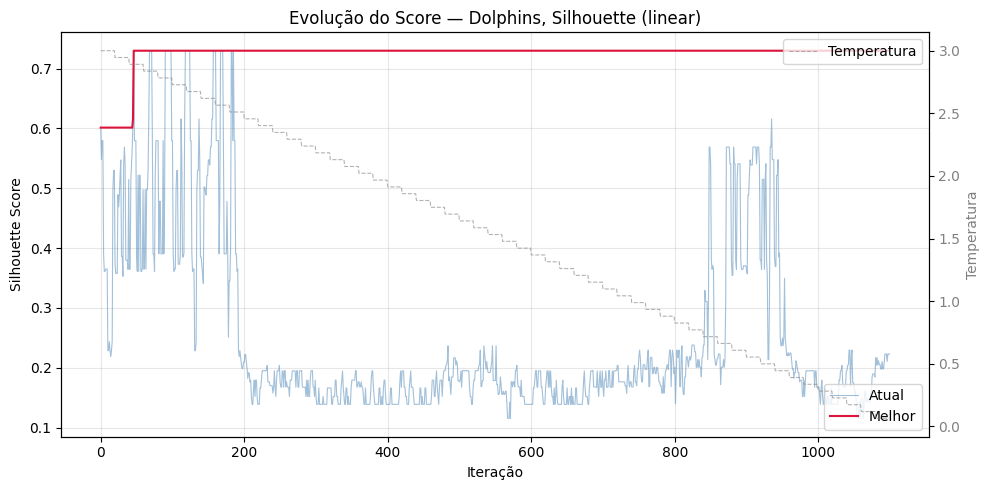

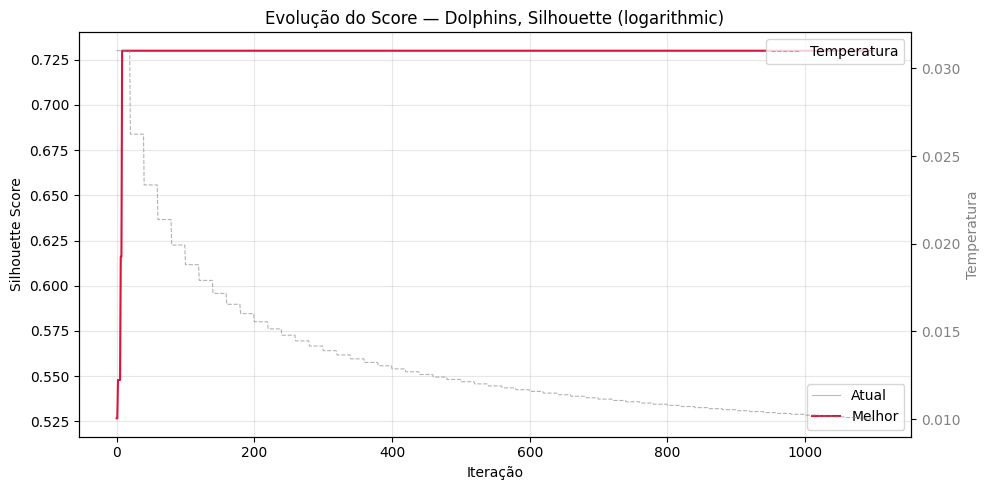

In [10]:
for schedule in COOLING_SCHEDULES:
    plot_silhouette_history(
        dolphins_sil[schedule]['history'],
        title=f"Evolução do Score — Dolphins, Silhouette ({schedule})",
        save_path=os.path.join(IMG_DIR, 'dolphins', f"dolphins_sil_history_{schedule}.png")
    )


### 3.3 Estatísticas de visita por Nº de comunidades — Dolphins

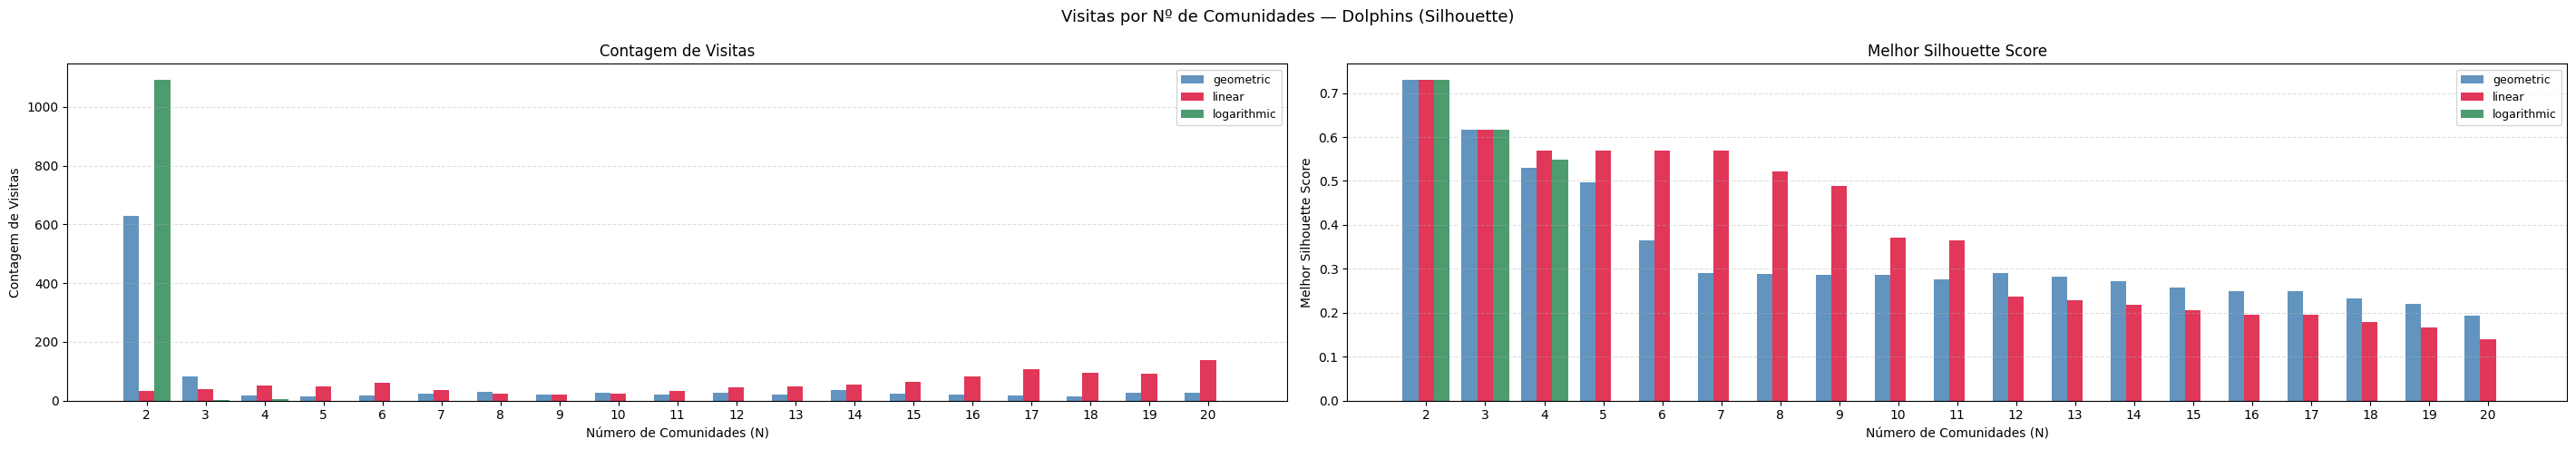

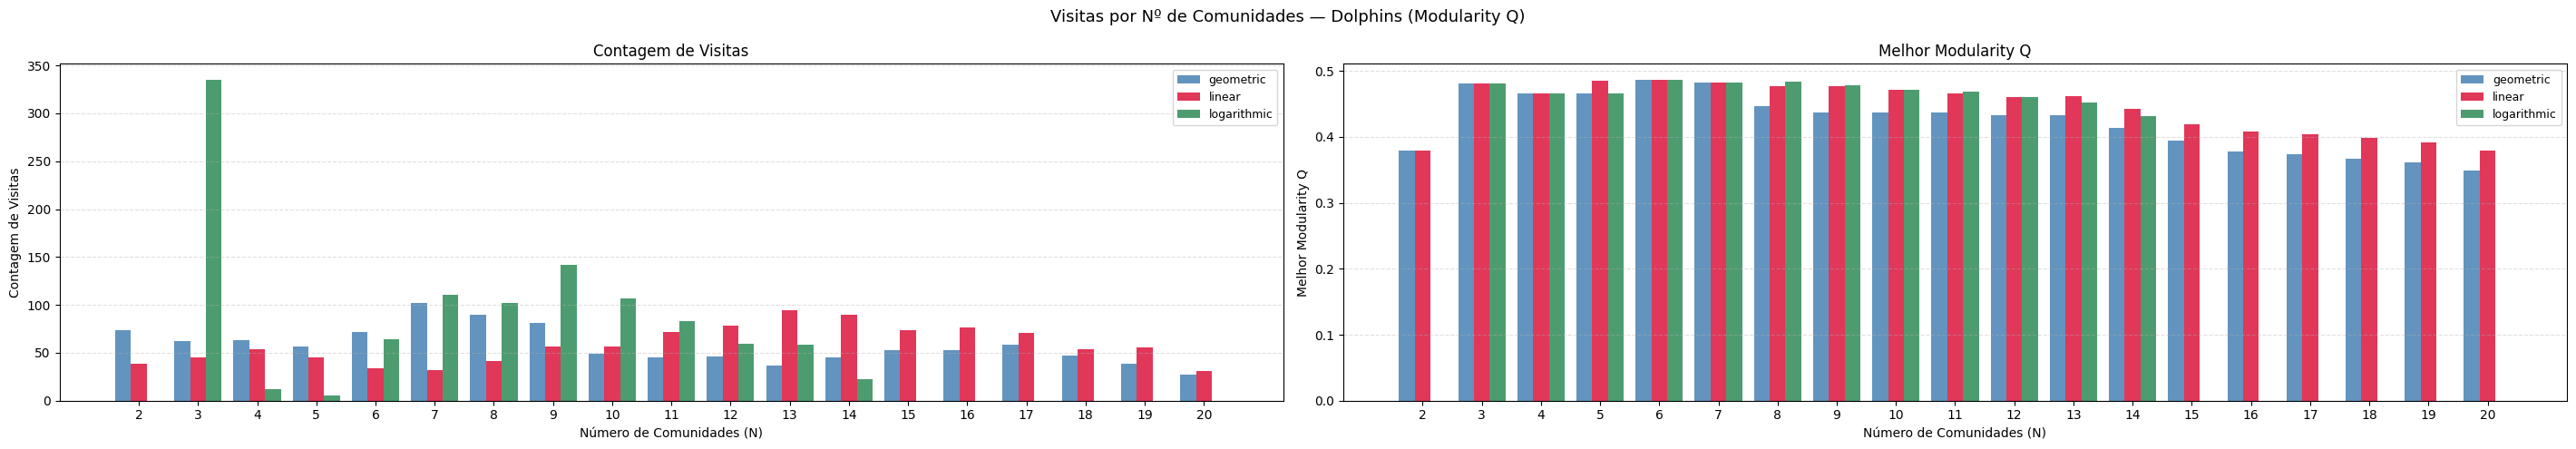

In [11]:
plot_n_communities_stats(
    histories=[dolphins_sil[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Dolphins (Silhouette)",
    score_label="Melhor Silhouette Score",
    save_path=os.path.join(IMG_DIR, 'dolphins', "dolphins_n_communities_sil.png")
)
plot_n_communities_stats(
    histories=[dolphins_mod[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Dolphins (Modularity Q)",
    score_label="Melhor Modularity Q",
    save_path=os.path.join(IMG_DIR, 'dolphins', "dolphins_n_communities_mod.png")
)


## 4. Political Books — Comparação de Funções de Resfriamento

Rede de co-compra de livros políticos (Krebs) com 105 nós. Ground truth: 0=liberal, 1=neutro, 2=conservador.

In [12]:
G_polbooks, true_labels_polbooks = load_polbooks(os.path.join(DATA_DIR, 'polbooks.zip'))
print(f"Nós: {G_polbooks.number_of_nodes()}, Arestas: {G_polbooks.number_of_edges()}")
print(f"Classes únicas: {sorted(set(true_labels_polbooks))}")

Delta_polbooks, _, _ = build_dissimilarity(G_polbooks)
print("Matriz de dissimilaridade calculada.")

Nós: 105, Arestas: 441
Classes únicas: [0, 1, 2]
Matriz de dissimilaridade calculada.


In [13]:
random.seed(42)
print("=== Political Books ===")
polbooks_sil, polbooks_mod, polbooks_best_sil_s, polbooks_best_mod_s = run_both_objectives(
    G_polbooks, Delta_polbooks, true_labels_polbooks, 'polbooks', has_gt=True)
polbooks_sil_best = polbooks_sil[polbooks_best_sil_s]
polbooks_mod_best = polbooks_mod[polbooks_best_mod_s]


=== Political Books ===
  [sil] geometric    | Comunidades: 2 | Sil: 0.6491 | ARI: 0.6671
  [mod] geometric    | Comunidades: 5 | Q: 0.5244 | ARI: 0.6024
  [sil] linear       | Comunidades: 2 | Sil: 0.6491 | ARI: 0.6671
  [mod] linear       | Comunidades: 4 | Q: 0.5240 | ARI: 0.6490
  [sil] logarithmic  | Comunidades: 2 | Sil: 0.6491 | ARI: 0.6671
  [mod] logarithmic  | Comunidades: 4 | Q: 0.5240 | ARI: 0.6490

  → Melhor Silhouette: geometric (0.6491)
  → Melhor Modularity: geometric (0.5244)


### 4.1 Detecção de comunidades vs. ground truth — por função de resfriamento

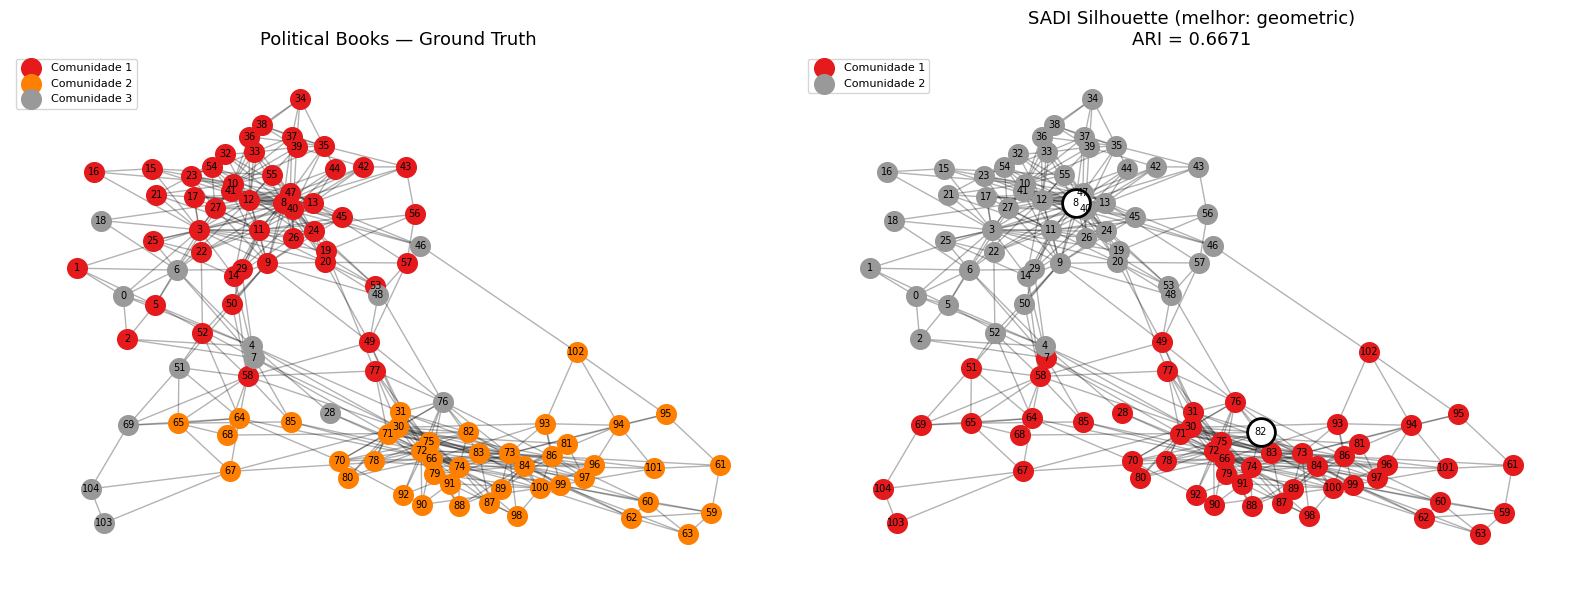

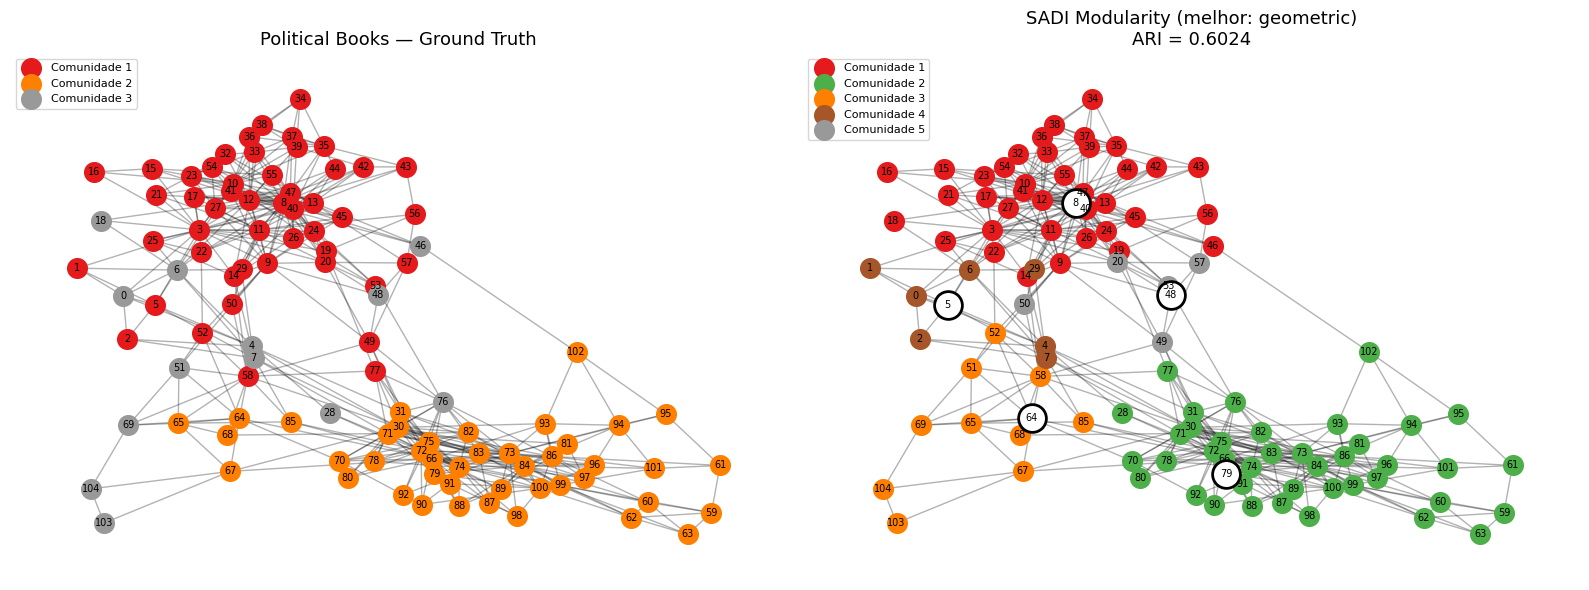

In [14]:
plot_comparison(
    G_polbooks, true_labels_polbooks, polbooks_sil_best['labels'], polbooks_sil_best['centers'],
    title_true="Political Books — Ground Truth",
    title_pred=f"SADI Silhouette (melhor: {polbooks_best_sil_s})",
    ari=polbooks_sil_best['ari'],
    save_path=os.path.join(IMG_DIR, 'polbooks', "polbooks_comparacao_sil_best.png")
)
plot_comparison(
    G_polbooks, true_labels_polbooks, polbooks_mod_best['labels'], polbooks_mod_best['centers'],
    title_true="Political Books — Ground Truth",
    title_pred=f"SADI Modularity (melhor: {polbooks_best_mod_s})",
    ari=polbooks_mod_best['ari'],
    save_path=os.path.join(IMG_DIR, 'polbooks', "polbooks_comparacao_mod_best.png")
)


### 4.2 Evolução do Silhouette Score — por função de resfriamento

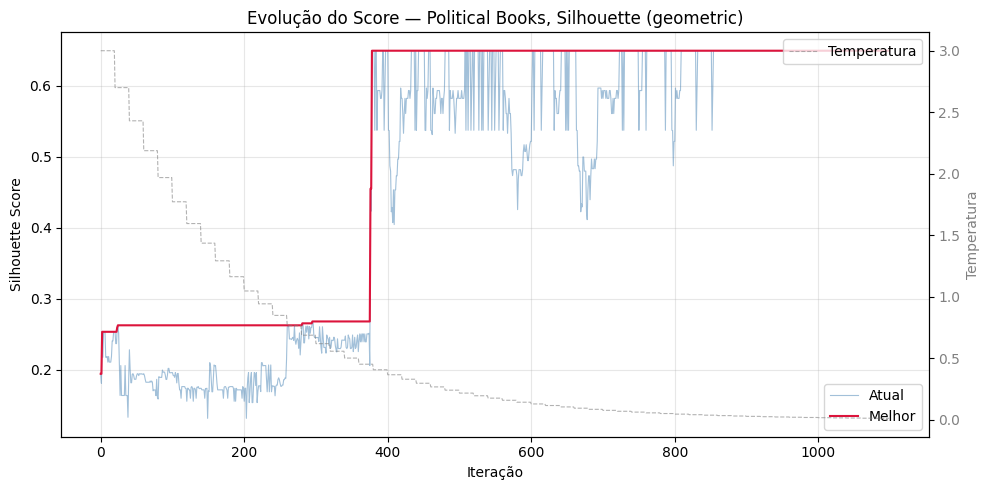

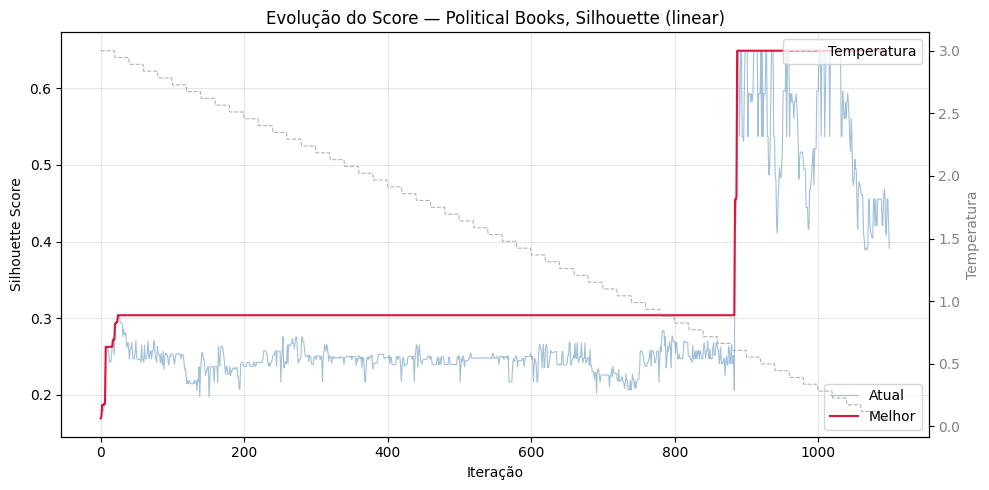

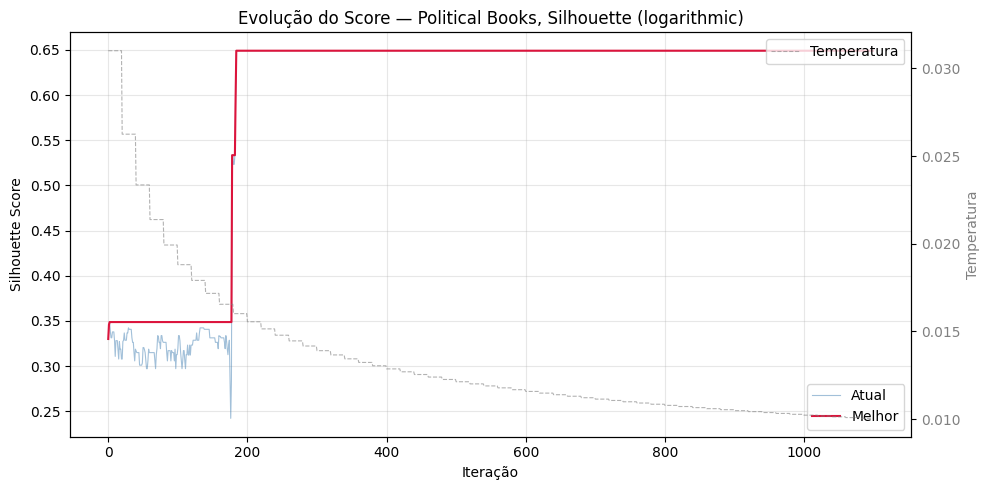

In [15]:
for schedule in COOLING_SCHEDULES:
    plot_silhouette_history(
        polbooks_sil[schedule]['history'],
        title=f"Evolução do Score — Political Books, Silhouette ({schedule})",
        save_path=os.path.join(IMG_DIR, 'polbooks', f"polbooks_sil_history_{schedule}.png")
    )


### 4.3 Estatísticas de visita por Nº de comunidades — Political Books

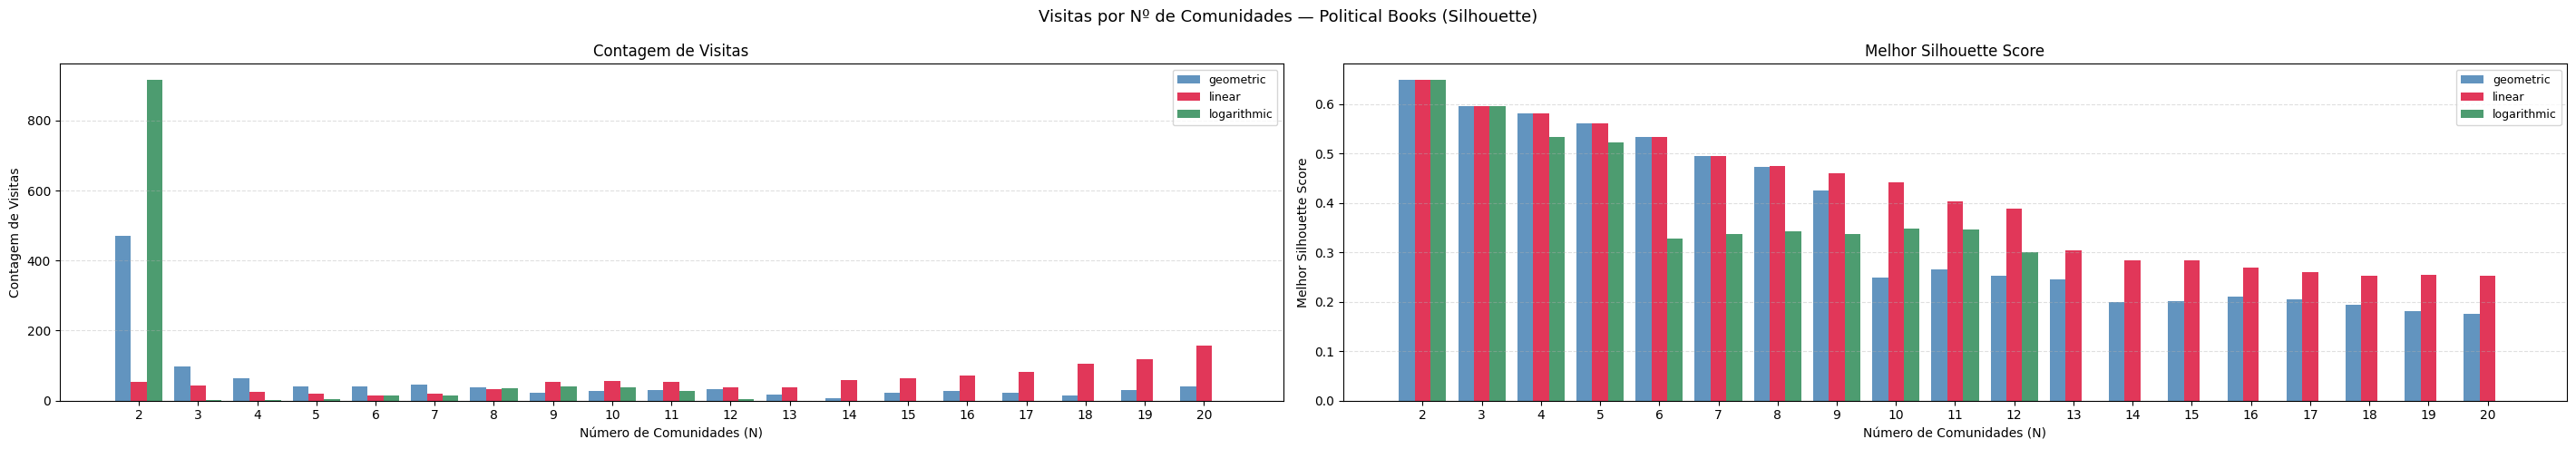

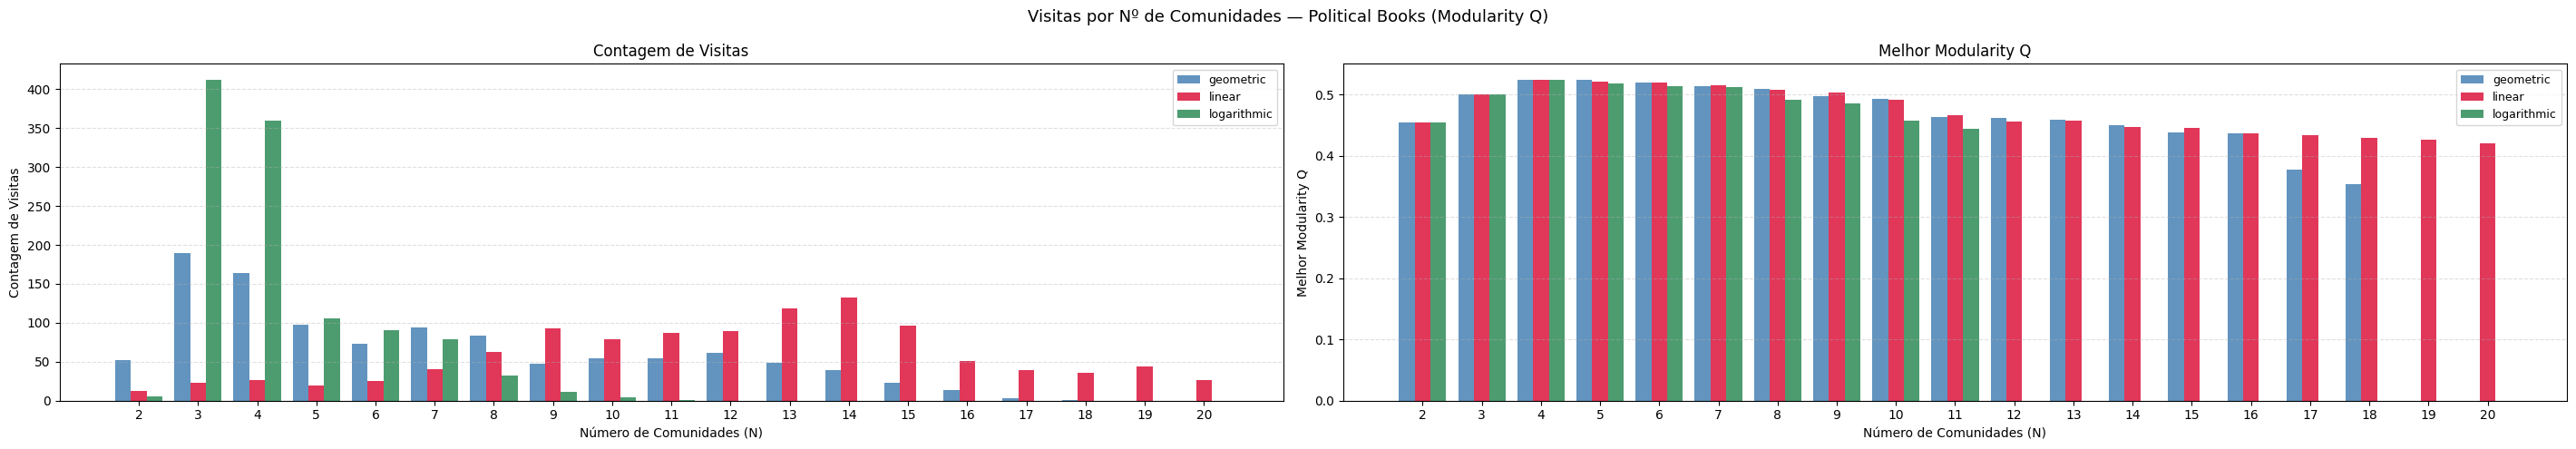

In [16]:
plot_n_communities_stats(
    histories=[polbooks_sil[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Political Books (Silhouette)",
    score_label="Melhor Silhouette Score",
    save_path=os.path.join(IMG_DIR, 'polbooks', "polbooks_n_communities_sil.png")
)
plot_n_communities_stats(
    histories=[polbooks_mod[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Political Books (Modularity Q)",
    score_label="Melhor Modularity Q",
    save_path=os.path.join(IMG_DIR, 'polbooks', "polbooks_n_communities_mod.png")
)


## 5. Les Misérables — Comparação de Funções de Resfriamento

Rede de co-aparições de personagens de Les Misérables (Knuth) com 77 nós. Grafo ponderado. Sem ground truth oficial.

In [17]:
G_lesmis, true_labels_lesmis = load_lesmis(os.path.join(DATA_DIR, 'lesmis.zip'))
print(f"Nós: {G_lesmis.number_of_nodes()}, Arestas: {G_lesmis.number_of_edges()}")

Delta_lesmis, _, _ = build_dissimilarity(G_lesmis)
print("Matriz de dissimilaridade calculada.")

Nós: 77, Arestas: 254
Matriz de dissimilaridade calculada.


In [18]:
random.seed(42)
print("=== Les Misérables ===")
lesmis_sil, lesmis_mod, lesmis_best_sil_s, lesmis_best_mod_s = run_both_objectives(
    G_lesmis, Delta_lesmis, None, 'lesmis', has_gt=False)
lesmis_sil_best = lesmis_sil[lesmis_best_sil_s]
lesmis_mod_best = lesmis_mod[lesmis_best_mod_s]


=== Les Misérables ===
  [sil] geometric    | Comunidades: 6 | Sil: 0.4831
  [mod] geometric    | Comunidades: 6 | Q: 0.5306
  [sil] linear       | Comunidades: 11 | Sil: 0.6172
  [mod] linear       | Comunidades: 5 | Q: 0.5333
  [sil] logarithmic  | Comunidades: 8 | Sil: 0.4669
  [mod] logarithmic  | Comunidades: 8 | Q: 0.5342

  → Melhor Silhouette: linear (0.6172)
  → Melhor Modularity: logarithmic (0.5342)


### 5.1 Comunidades detectadas — por função de resfriamento

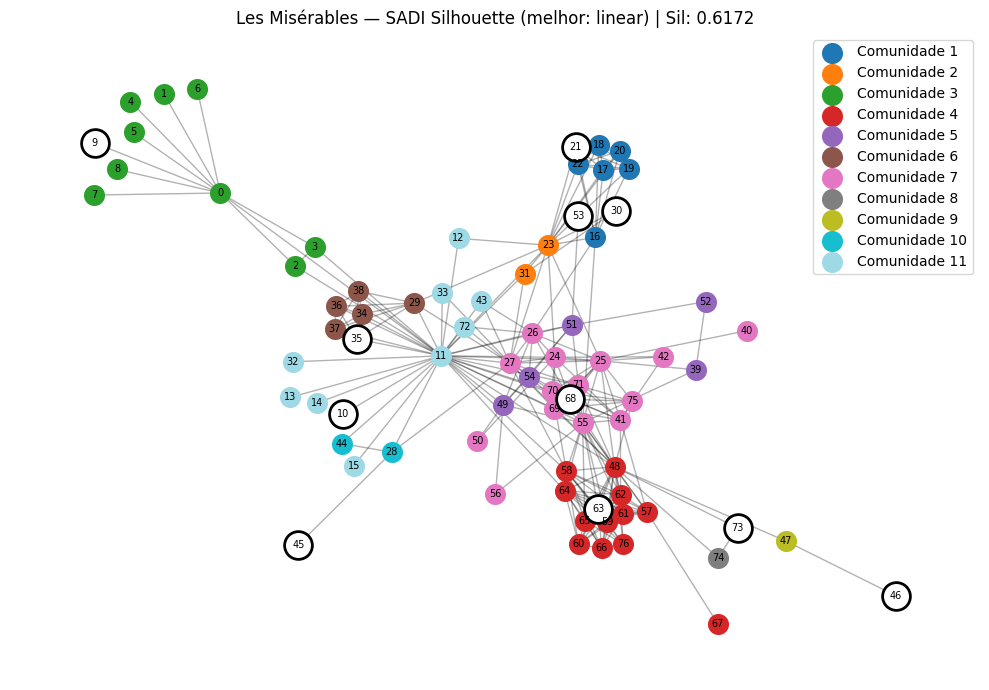

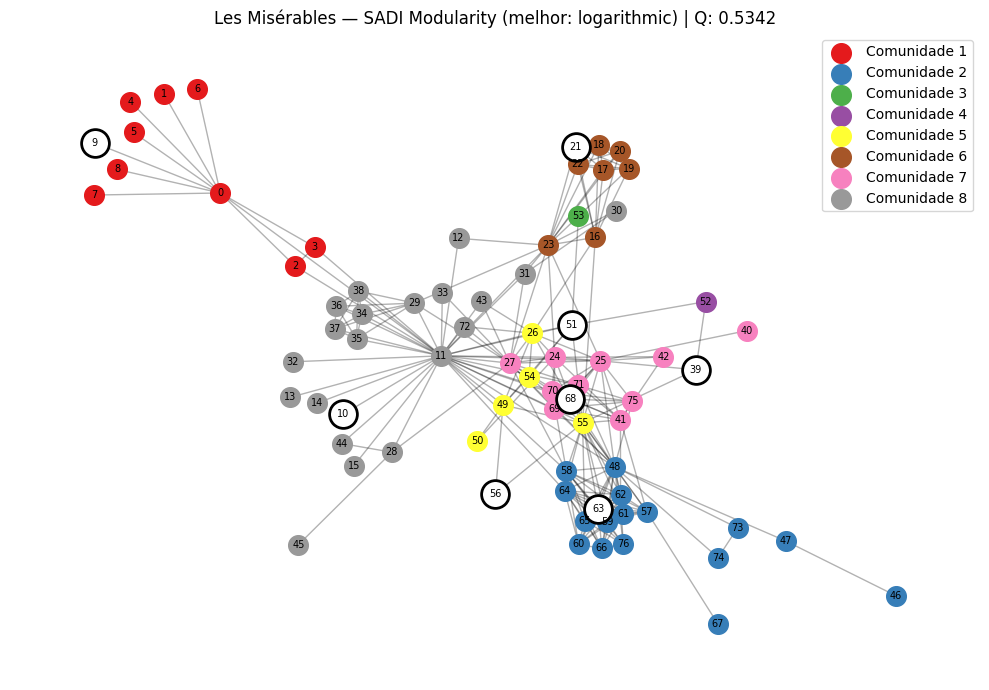

In [19]:
plot_communities(
    G_lesmis, lesmis_sil_best['labels'], lesmis_sil_best['centers'],
    title=f"Les Misérables — SADI Silhouette (melhor: {lesmis_best_sil_s}) | Sil: {lesmis_sil_best['score']:.4f}",
    save_path=os.path.join(IMG_DIR, 'lesmis', "lesmis_sil_best.png")
)
plot_communities(
    G_lesmis, lesmis_mod_best['labels'], lesmis_mod_best['centers'],
    title=f"Les Misérables — SADI Modularity (melhor: {lesmis_best_mod_s}) | Q: {lesmis_mod_best['score']:.4f}",
    save_path=os.path.join(IMG_DIR, 'lesmis', "lesmis_mod_best.png")
)


### 5.2 Evolução do Silhouette Score — por função de resfriamento

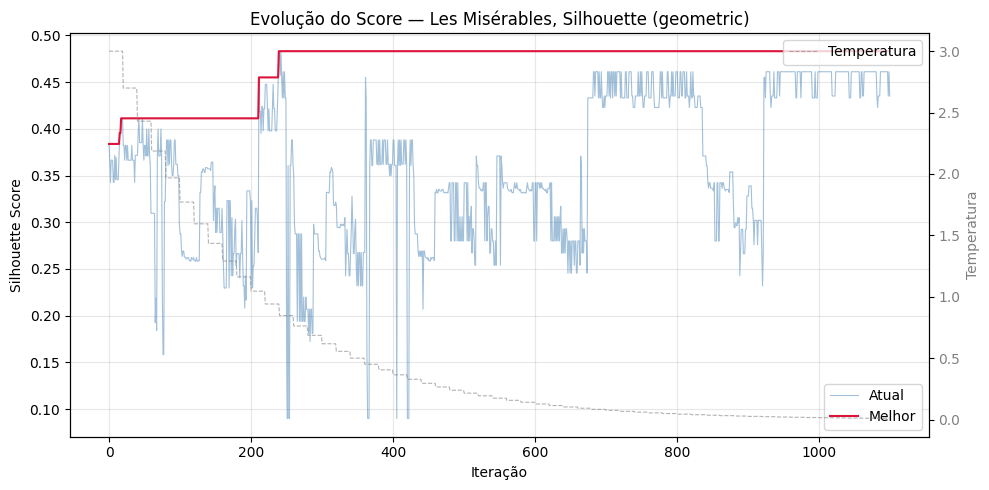

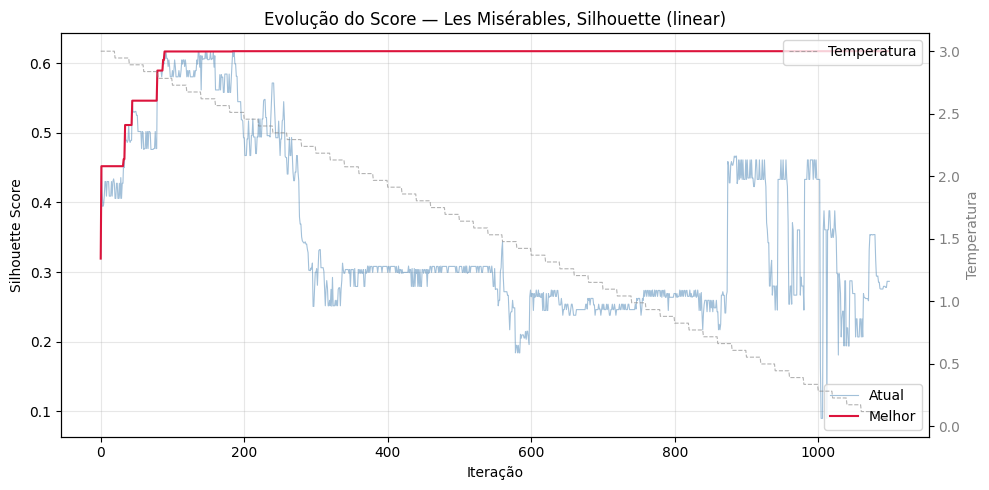

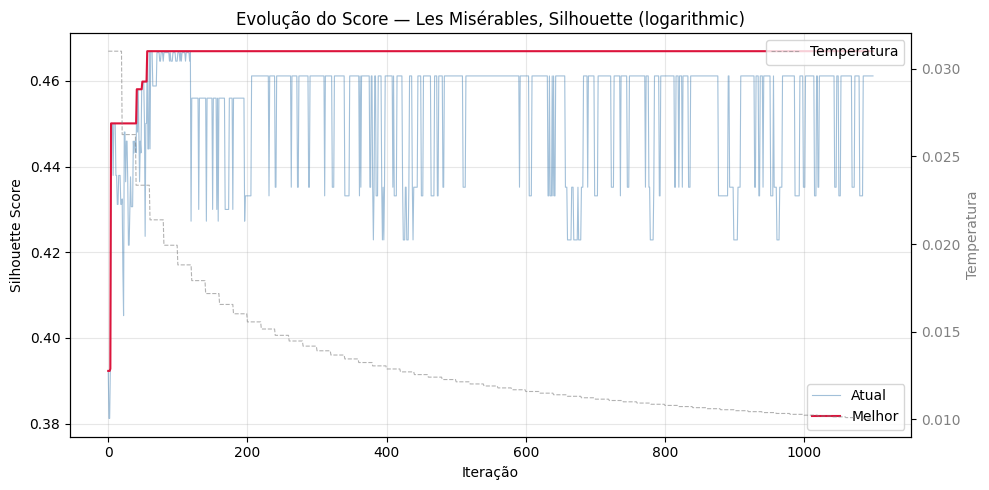

In [20]:
for schedule in COOLING_SCHEDULES:
    plot_silhouette_history(
        lesmis_sil[schedule]['history'],
        title=f"Evolução do Score — Les Misérables, Silhouette ({schedule})",
        save_path=os.path.join(IMG_DIR, 'lesmis', f"lesmis_sil_history_{schedule}.png")
    )


### 5.3 Estatísticas de visita por Nº de comunidades — Les Misérables

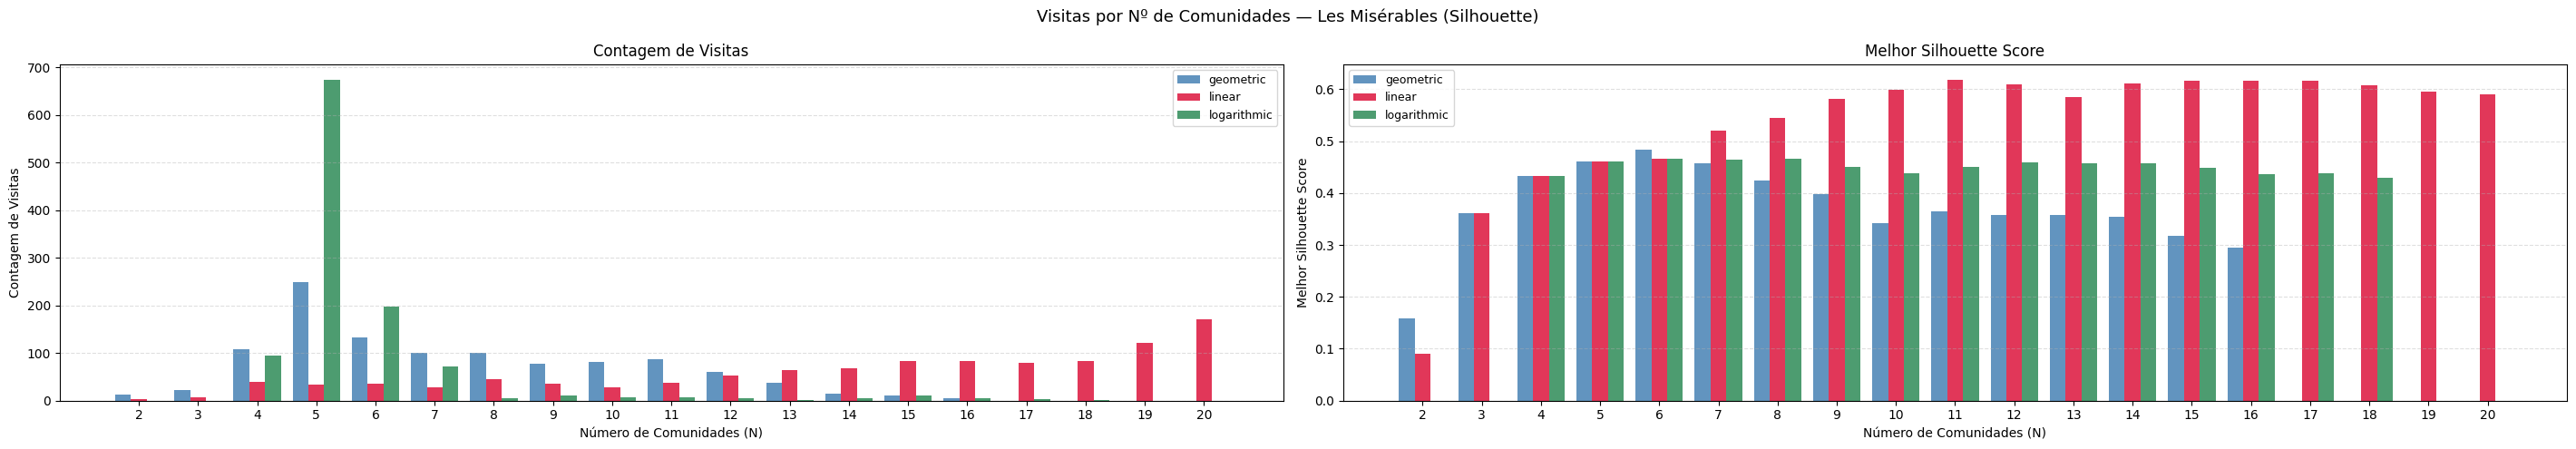

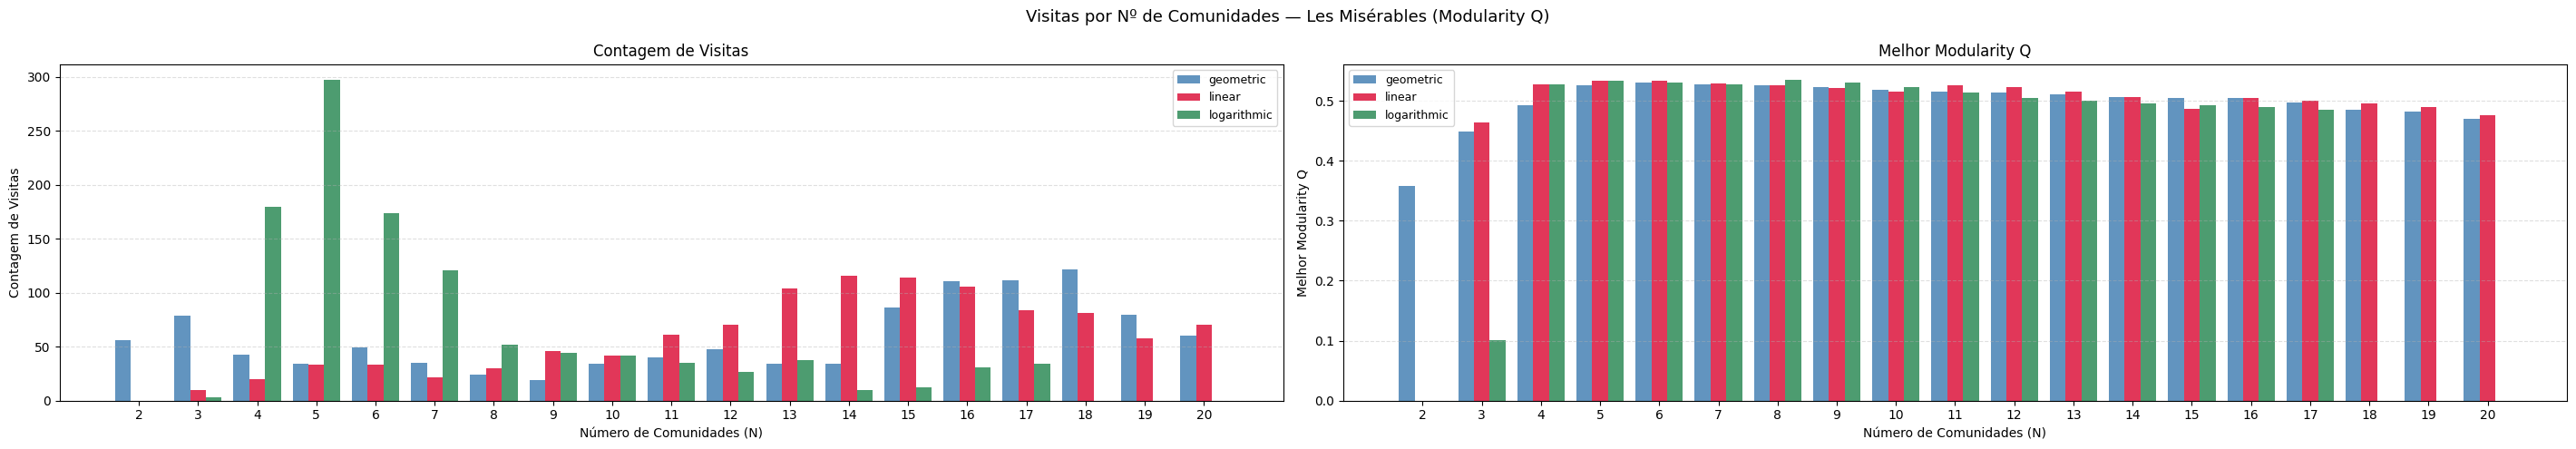

In [21]:
plot_n_communities_stats(
    histories=[lesmis_sil[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Les Misérables (Silhouette)",
    score_label="Melhor Silhouette Score",
    save_path=os.path.join(IMG_DIR, 'lesmis', "lesmis_n_communities_sil.png")
)
plot_n_communities_stats(
    histories=[lesmis_mod[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Les Misérables (Modularity Q)",
    score_label="Melhor Modularity Q",
    save_path=os.path.join(IMG_DIR, 'lesmis', "lesmis_n_communities_mod.png")
)


## 6. Football (NCAA) — Comparação de Funções de Resfriamento

Rede de jogos entre times universitários (Girvan & Newman) com 115 nós. Ground truth: conferência de cada time (0–11).

In [22]:
G_football, true_labels_football = load_football(os.path.join(DATA_DIR, 'football.zip'))
print(f"Nós: {G_football.number_of_nodes()}, Arestas: {G_football.number_of_edges()}")
print(f"Conferências únicas: {sorted(set(true_labels_football))}")

Delta_football, _, _ = build_dissimilarity(G_football)
print("Matriz de dissimilaridade calculada.")

Nós: 115, Arestas: 613
Conferências únicas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Matriz de dissimilaridade calculada.


In [23]:
random.seed(42)
print("=== Football ===")
football_sil, football_mod, football_best_sil_s, football_best_mod_s = run_both_objectives(
    G_football, Delta_football, true_labels_football, 'football', has_gt=True)
football_sil_best = football_sil[football_best_sil_s]
football_mod_best = football_mod[football_best_mod_s]


=== Football ===
  [sil] geometric    | Comunidades: 12 | Sil: 0.5737 | ARI: 0.8927
  [mod] geometric    | Comunidades: 10 | Q: 0.6005 | ARI: 0.7837
  [sil] linear       | Comunidades: 12 | Sil: 0.5737 | ARI: 0.8927
  [mod] linear       | Comunidades: 11 | Q: 0.5982 | ARI: 0.8494
  [sil] logarithmic  | Comunidades: 12 | Sil: 0.5737 | ARI: 0.8927
  [mod] logarithmic  | Comunidades: 11 | Q: 0.5982 | ARI: 0.8494

  → Melhor Silhouette: geometric (0.5737)
  → Melhor Modularity: geometric (0.6005)


### 6.1 Detecção de comunidades vs. ground truth — por função de resfriamento

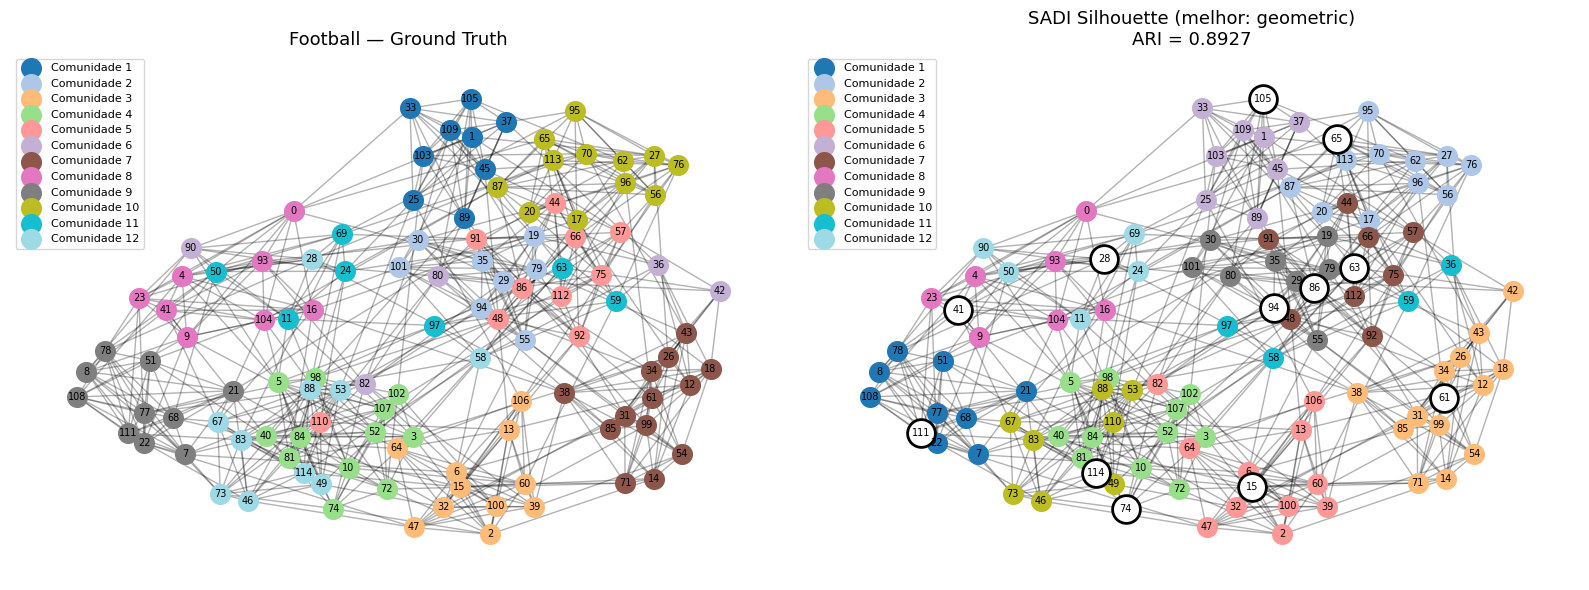

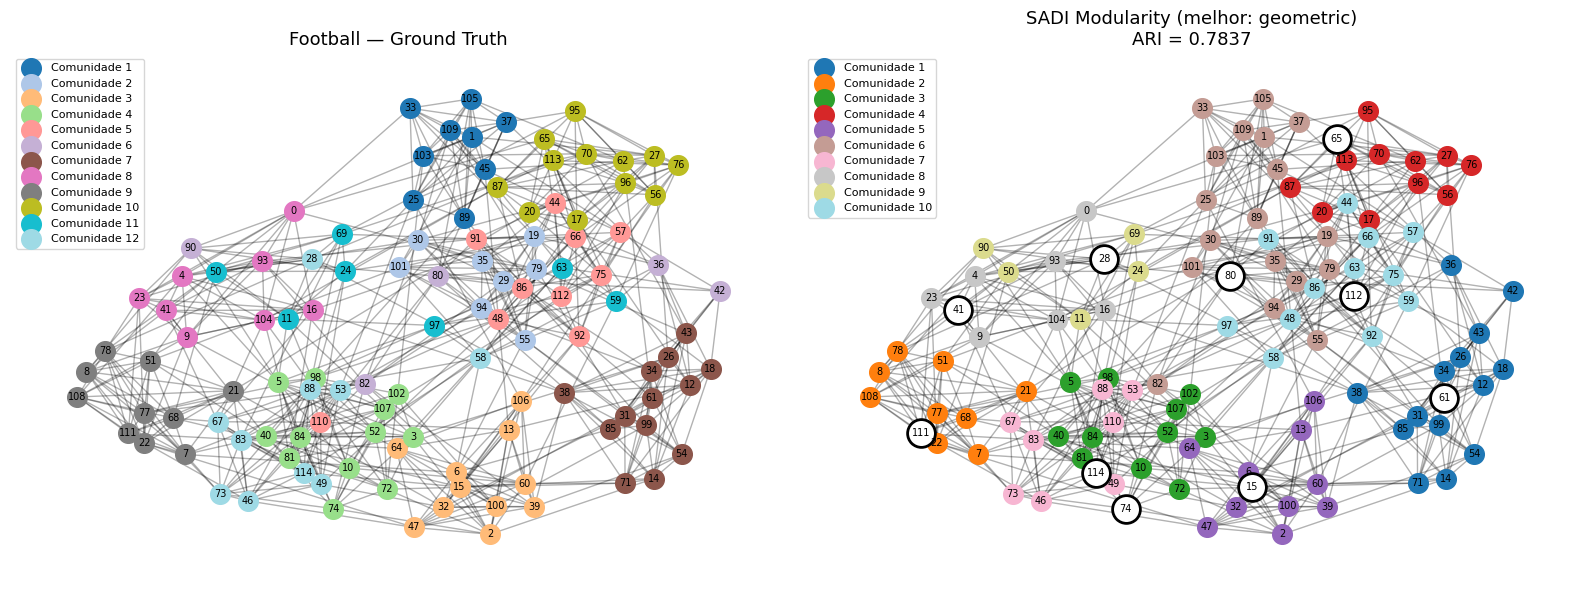

In [24]:
plot_comparison(
    G_football, true_labels_football, football_sil_best['labels'], football_sil_best['centers'],
    title_true="Football — Ground Truth",
    title_pred=f"SADI Silhouette (melhor: {football_best_sil_s})",
    ari=football_sil_best['ari'],
    save_path=os.path.join(IMG_DIR, 'football', "football_comparacao_sil_best.png")
)
plot_comparison(
    G_football, true_labels_football, football_mod_best['labels'], football_mod_best['centers'],
    title_true="Football — Ground Truth",
    title_pred=f"SADI Modularity (melhor: {football_best_mod_s})",
    ari=football_mod_best['ari'],
    save_path=os.path.join(IMG_DIR, 'football', "football_comparacao_mod_best.png")
)


### 6.2 Evolução do Silhouette Score — por função de resfriamento

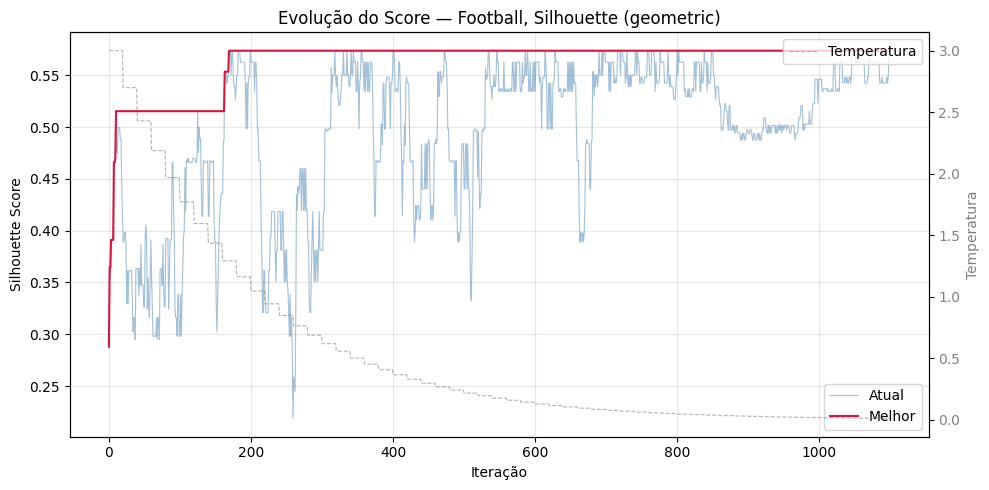

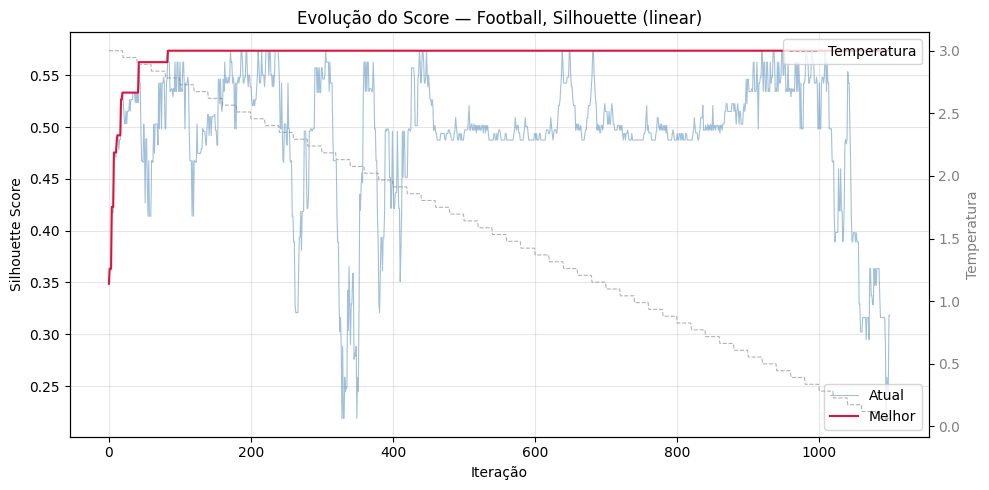

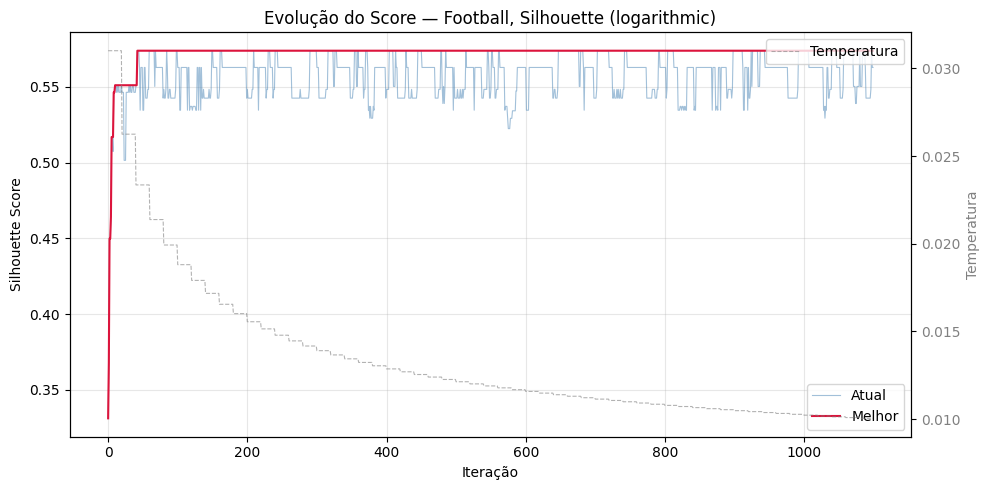

In [25]:
for schedule in COOLING_SCHEDULES:
    plot_silhouette_history(
        football_sil[schedule]['history'],
        title=f"Evolução do Score — Football, Silhouette ({schedule})",
        save_path=os.path.join(IMG_DIR, 'football', f"football_sil_history_{schedule}.png")
    )


### 6.3 Estatísticas de visita por Nº de comunidades — Football

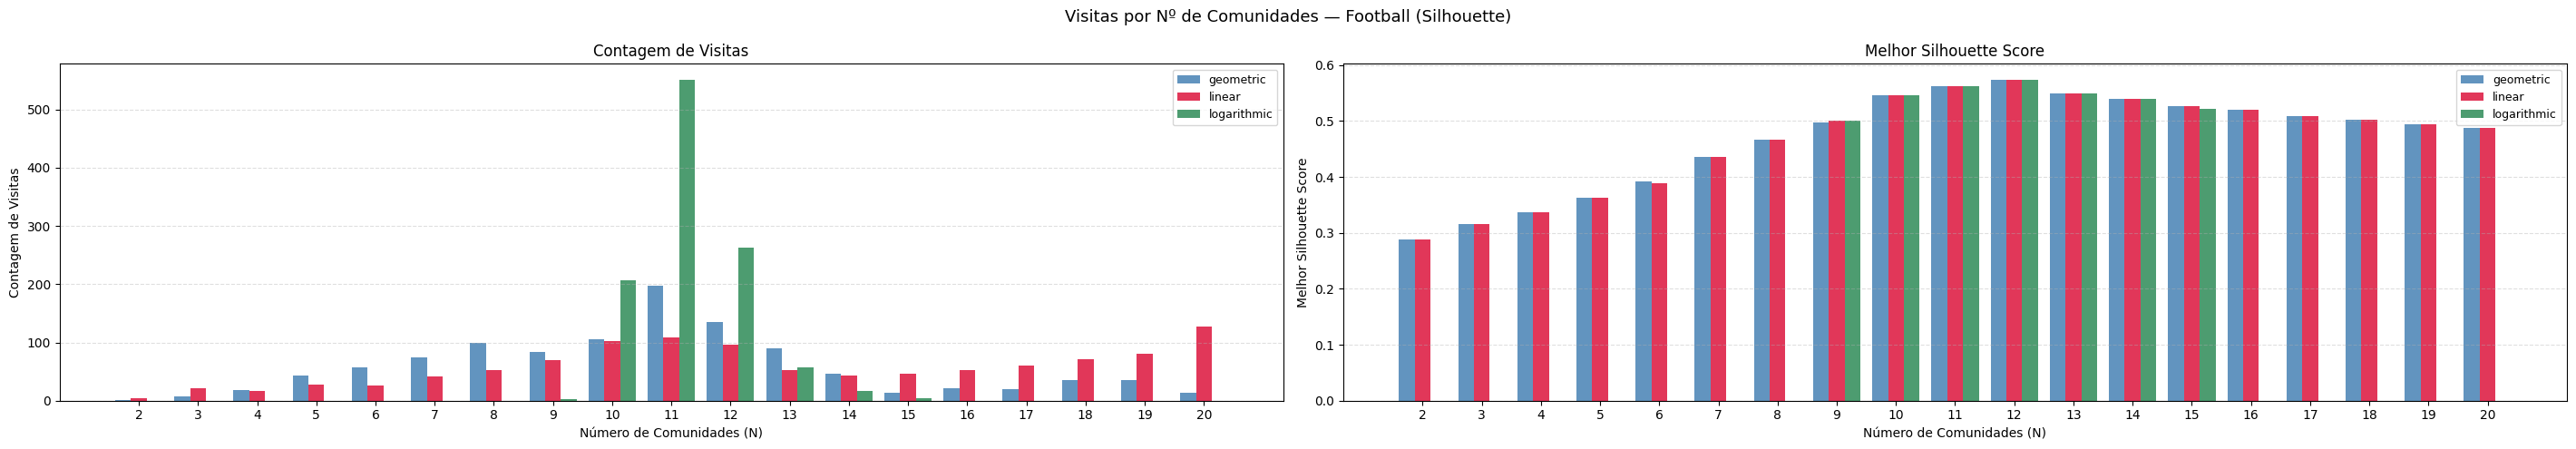

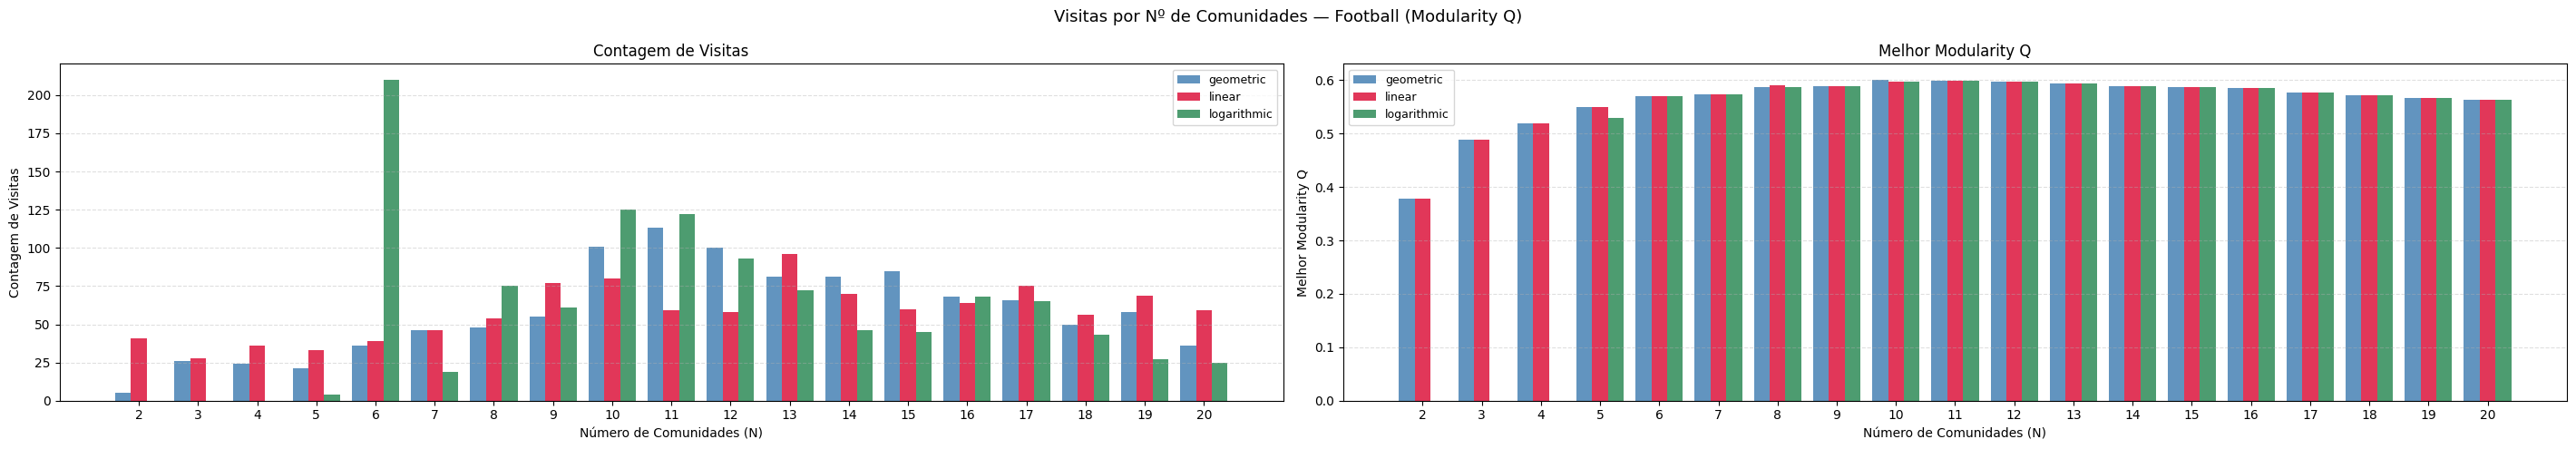

In [26]:
plot_n_communities_stats(
    histories=[football_sil[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Football (Silhouette)",
    score_label="Melhor Silhouette Score",
    save_path=os.path.join(IMG_DIR, 'football', "football_n_communities_sil.png")
)
plot_n_communities_stats(
    histories=[football_mod[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Football (Modularity Q)",
    score_label="Melhor Modularity Q",
    save_path=os.path.join(IMG_DIR, 'football', "football_n_communities_mod.png")
)


## 7. Rede Ad Hoc (SBM) — Comparação de Funções de Resfriamento

Rede sintética com 128 nós, 4 comunidades, grau médio 16 e z_out=3 (parâmetro padrão do artigo Liu & Liu). Ground truth fornecido pelo modelo de blocos estocásticos.

In [27]:
G_adhoc, true_labels_adhoc = generate_ad_hoc_network(n=128, num_communities=4, z_out=3, seed=42)
print(f"Nós: {G_adhoc.number_of_nodes()}, Arestas: {G_adhoc.number_of_edges()}")

Delta_adhoc, _, _ = build_dissimilarity(G_adhoc)
print("Matriz de dissimilaridade calculada.")

Nós: 128, Arestas: 988
Matriz de dissimilaridade calculada.


In [28]:
random.seed(42)
print("=== Ad Hoc SBM ===")
adhoc_sil, adhoc_mod, adhoc_best_sil_s, adhoc_best_mod_s = run_both_objectives(
    G_adhoc, Delta_adhoc, true_labels_adhoc, 'adhoc', has_gt=True)
adhoc_sil_best = adhoc_sil[adhoc_best_sil_s]
adhoc_mod_best = adhoc_mod[adhoc_best_mod_s]


=== Ad Hoc SBM ===
  [sil] geometric    | Comunidades: 3 | Sil: 0.4525 | ARI: 0.7094
  [mod] geometric    | Comunidades: 4 | Q: 0.5561 | ARI: 1.0000
  [sil] linear       | Comunidades: 4 | Sil: 0.5706 | ARI: 1.0000
  [mod] linear       | Comunidades: 4 | Q: 0.5561 | ARI: 1.0000
  [sil] logarithmic  | Comunidades: 4 | Sil: 0.5706 | ARI: 1.0000
  [mod] logarithmic  | Comunidades: 4 | Q: 0.5561 | ARI: 1.0000

  → Melhor Silhouette: linear (0.5706)
  → Melhor Modularity: geometric (0.5561)


### 7.1 Detecção de comunidades vs. ground truth — por função de resfriamento

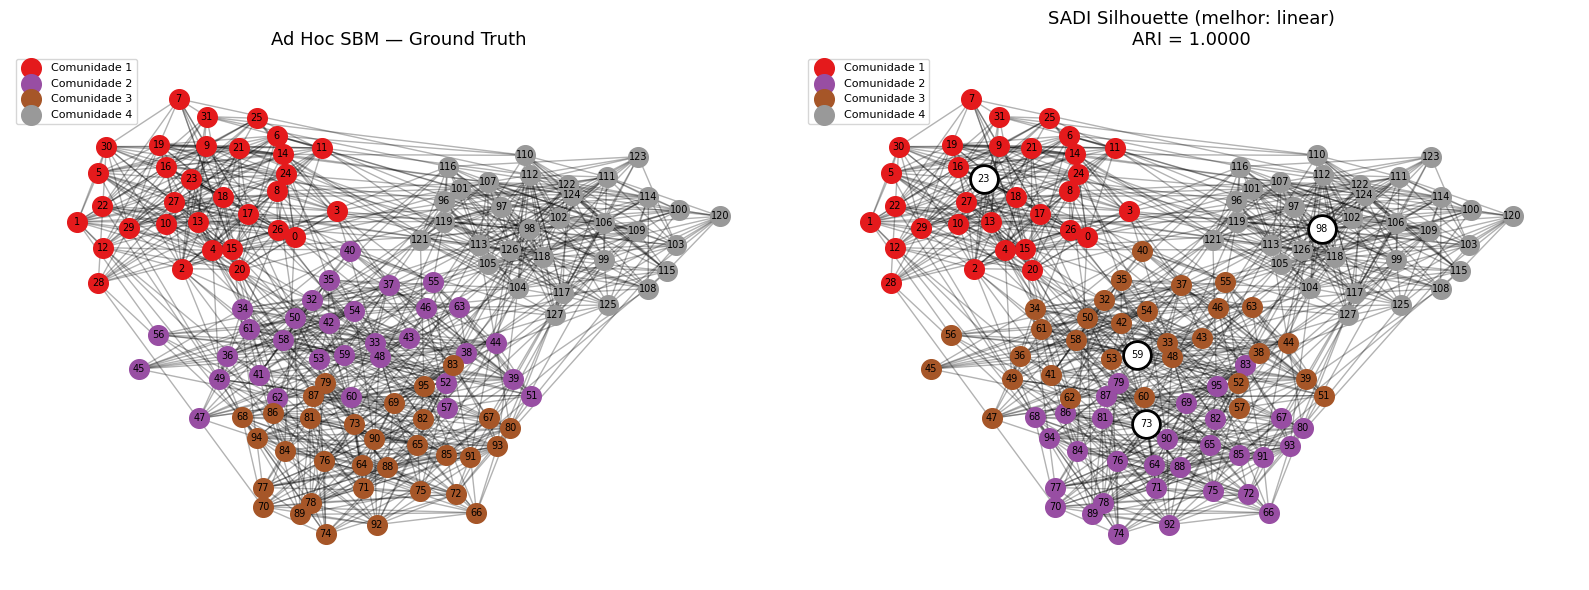

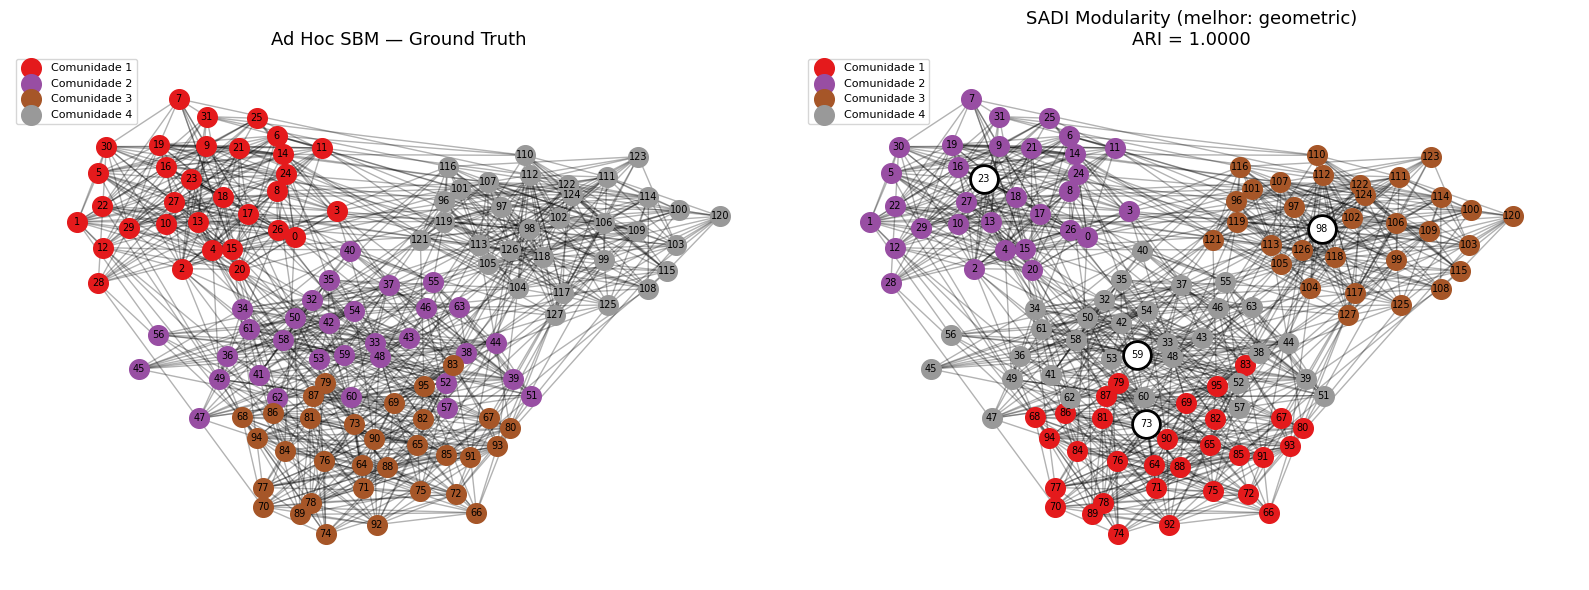

In [29]:
plot_comparison(
    G_adhoc, true_labels_adhoc, adhoc_sil_best['labels'], adhoc_sil_best['centers'],
    title_true="Ad Hoc SBM — Ground Truth",
    title_pred=f"SADI Silhouette (melhor: {adhoc_best_sil_s})",
    ari=adhoc_sil_best['ari'],
    save_path=os.path.join(IMG_DIR, 'adhoc', "adhoc_comparacao_sil_best.png")
)
plot_comparison(
    G_adhoc, true_labels_adhoc, adhoc_mod_best['labels'], adhoc_mod_best['centers'],
    title_true="Ad Hoc SBM — Ground Truth",
    title_pred=f"SADI Modularity (melhor: {adhoc_best_mod_s})",
    ari=adhoc_mod_best['ari'],
    save_path=os.path.join(IMG_DIR, 'adhoc', "adhoc_comparacao_mod_best.png")
)


### 7.2 Evolução do Silhouette Score — por função de resfriamento

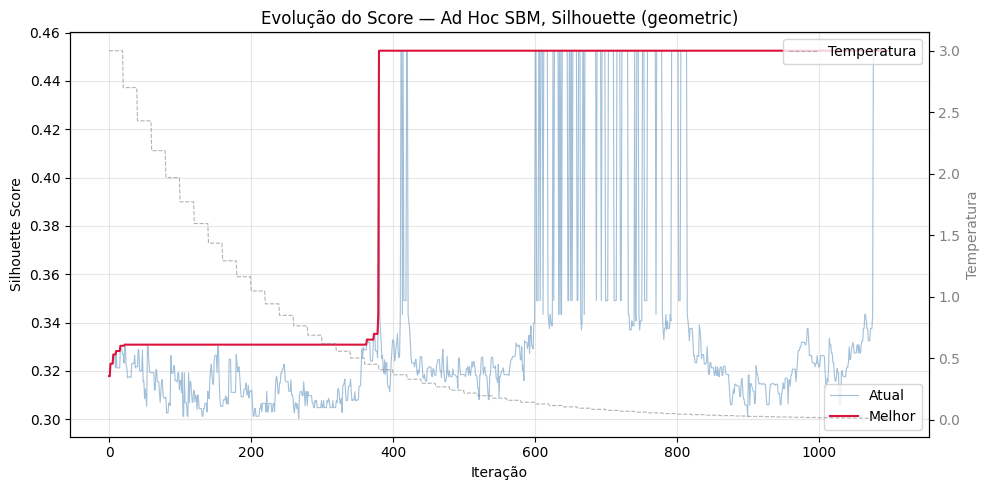

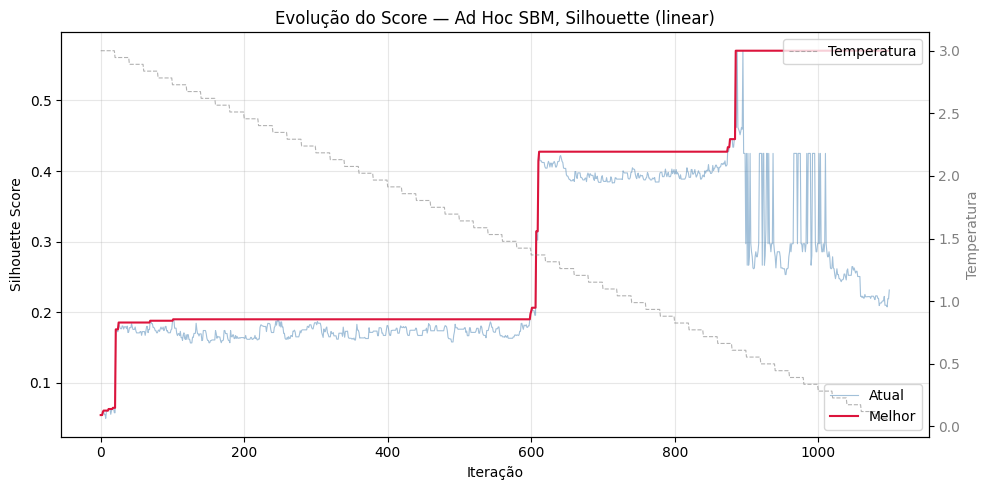

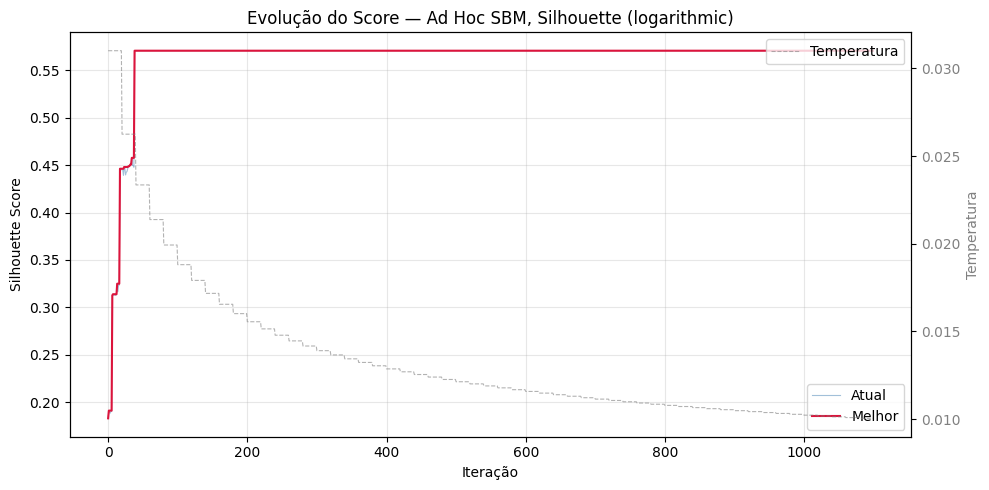

In [30]:
for schedule in COOLING_SCHEDULES:
    plot_silhouette_history(
        adhoc_sil[schedule]['history'],
        title=f"Evolução do Score — Ad Hoc SBM, Silhouette ({schedule})",
        save_path=os.path.join(IMG_DIR, 'adhoc', f"adhoc_sil_history_{schedule}.png")
    )


### 7.3 Estatísticas de visita por Nº de comunidades — Ad Hoc SBM

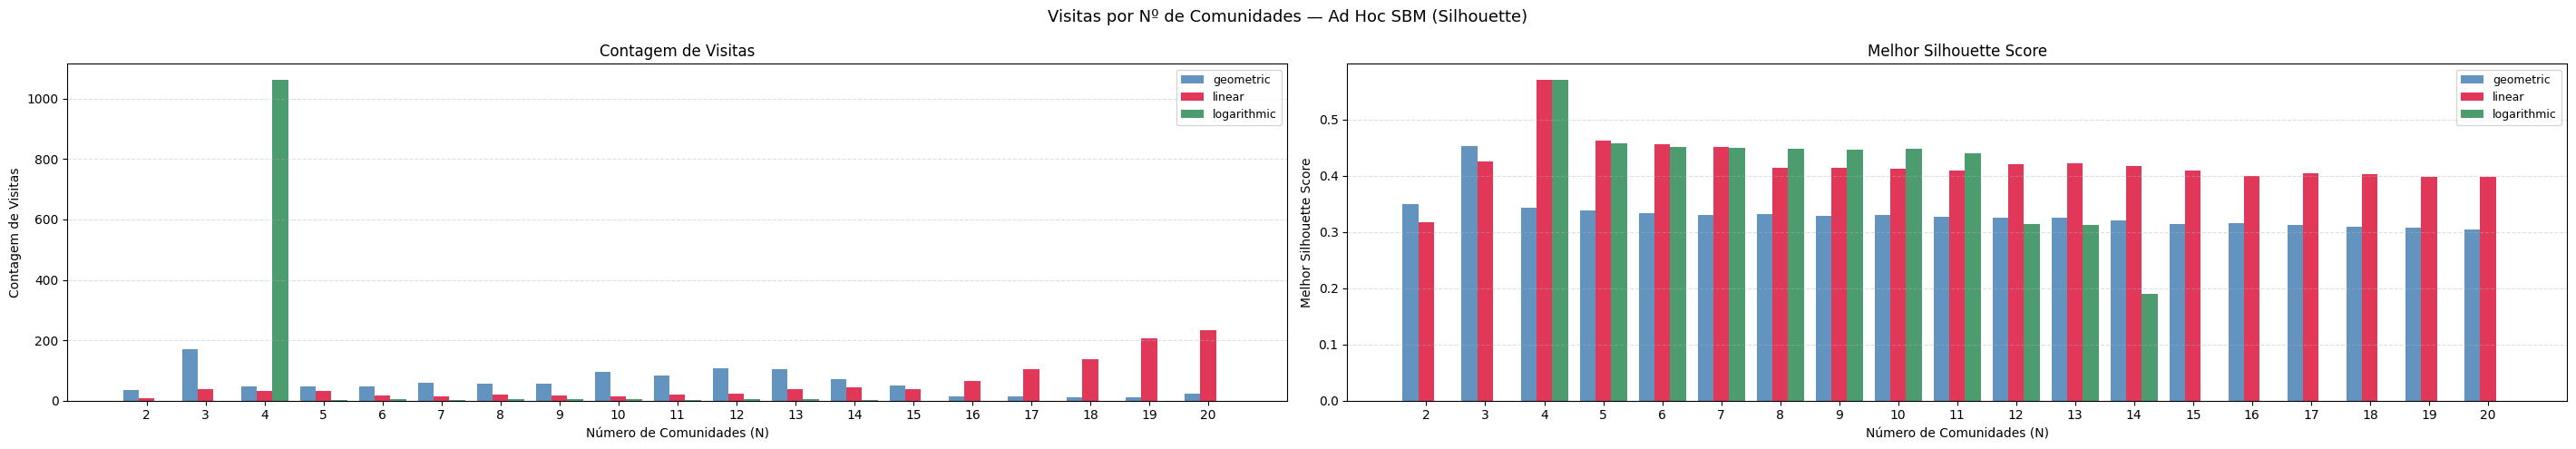

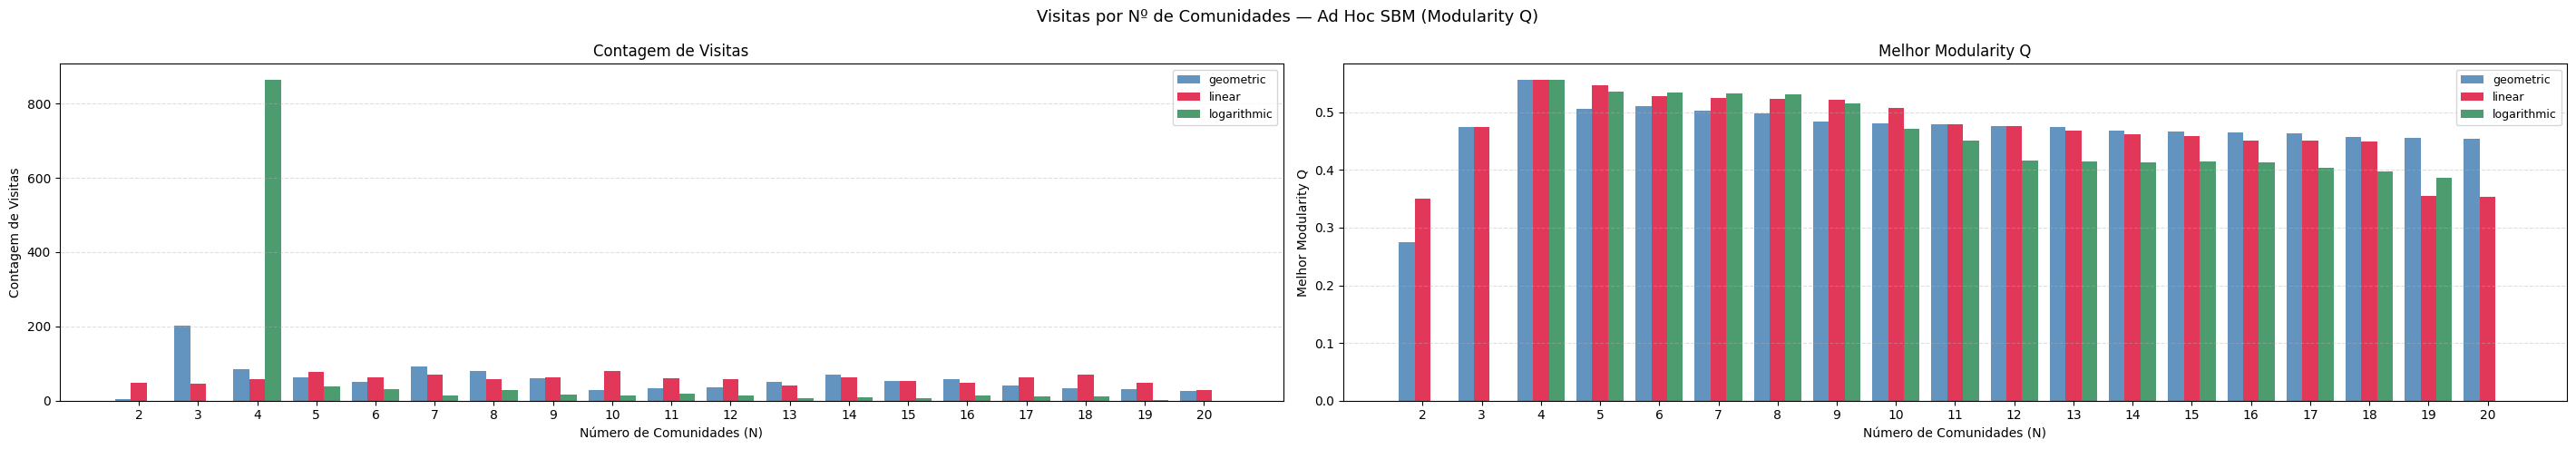

In [31]:
plot_n_communities_stats(
    histories=[adhoc_sil[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Ad Hoc SBM (Silhouette)",
    score_label="Melhor Silhouette Score",
    save_path=os.path.join(IMG_DIR, 'adhoc', "adhoc_n_communities_sil.png")
)
plot_n_communities_stats(
    histories=[adhoc_mod[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Ad Hoc SBM (Modularity Q)",
    score_label="Melhor Modularity Q",
    save_path=os.path.join(IMG_DIR, 'adhoc', "adhoc_n_communities_mod.png")
)


## 8. Rede Gaussiana — Comparação de Funções de Resfriamento

Rede sintética de 400 nós gerada por mistura de 3 gaussianas 2D. Conexões por limiar de distância euclidiana. Ground truth fornecido pela componente gaussiana de origem.

In [32]:
G_gauss, points_gauss, true_labels_gauss = generate_gaussian_network(n=400, dist_threshold=0.8, seed=42)
print(f"Nós: {G_gauss.number_of_nodes()}, Arestas: {G_gauss.number_of_edges()}")

Delta_gauss, _, _ = build_dissimilarity(G_gauss)
print("Matriz de dissimilaridade calculada.")

Nós: 400, Arestas: 18255
Matriz de dissimilaridade calculada.


In [33]:
random.seed(42)
print("=== Gaussiana ===")
gauss_sil, gauss_mod, gauss_best_sil_s, gauss_best_mod_s = run_both_objectives(
    G_gauss, Delta_gauss, true_labels_gauss, 'gaussian', has_gt=True)
gauss_sil_best = gauss_sil[gauss_best_sil_s]
gauss_mod_best = gauss_mod[gauss_best_mod_s]


=== Gaussiana ===
  [sil] geometric    | Comunidades: 3 | Sil: 0.9554 | ARI: 0.9931
  [mod] geometric    | Comunidades: 3 | Q: 0.6330 | ARI: 0.9931
  [sil] linear       | Comunidades: 3 | Sil: 0.9554 | ARI: 0.9931
  [mod] linear       | Comunidades: 3 | Q: 0.6330 | ARI: 0.9931
  [sil] logarithmic  | Comunidades: 3 | Sil: 0.9554 | ARI: 0.9931
  [mod] logarithmic  | Comunidades: 3 | Q: 0.6330 | ARI: 0.9931

  → Melhor Silhouette: geometric (0.9554)
  → Melhor Modularity: geometric (0.6330)


### 8.1 Detecção de comunidades vs. ground truth — por função de resfriamento

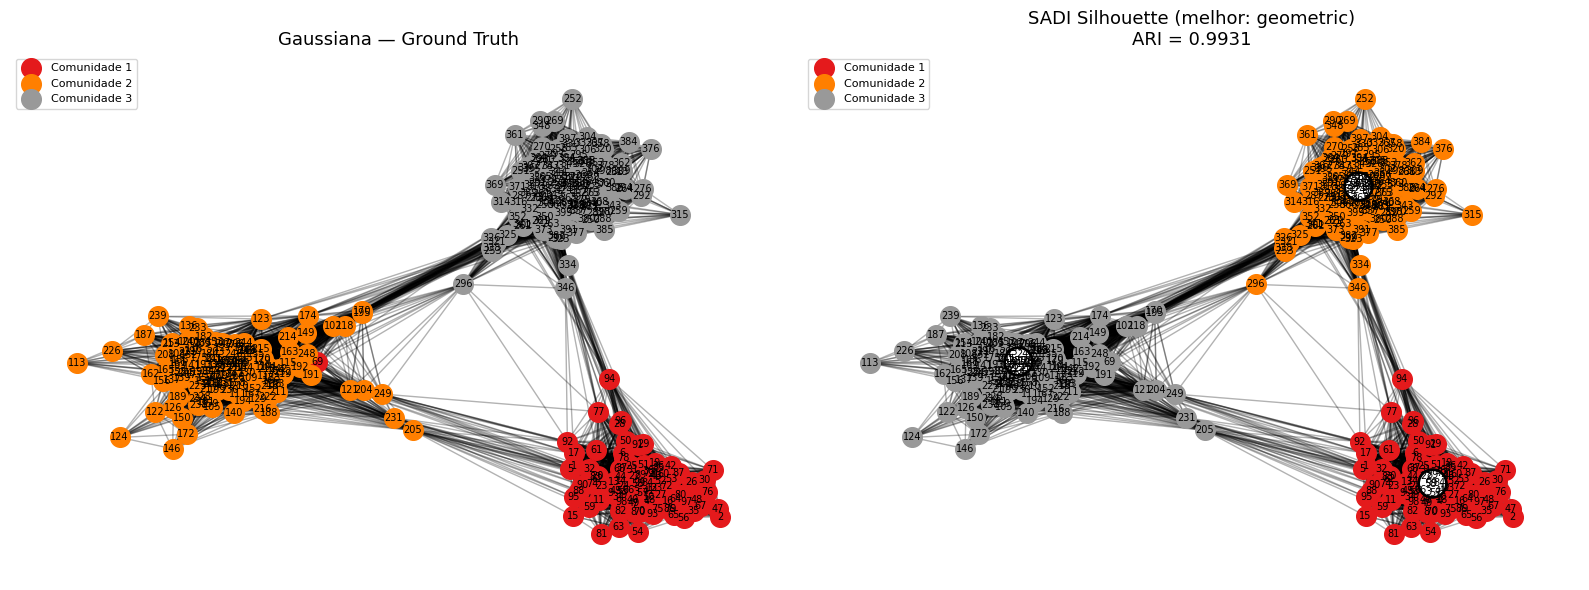

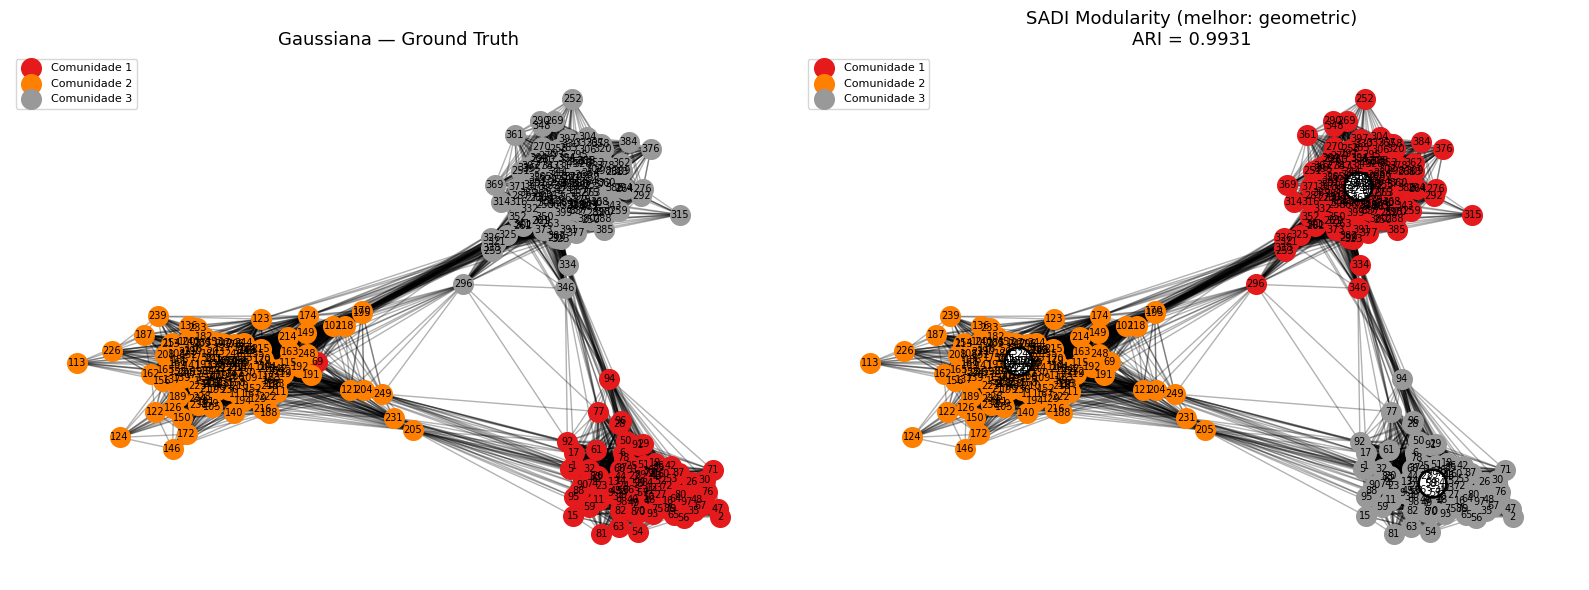

In [34]:
plot_comparison(
    G_gauss, true_labels_gauss, gauss_sil_best['labels'], gauss_sil_best['centers'],
    title_true="Gaussiana — Ground Truth",
    title_pred=f"SADI Silhouette (melhor: {gauss_best_sil_s})",
    ari=gauss_sil_best['ari'],
    save_path=os.path.join(IMG_DIR, 'gaussian', "gaussian_comparacao_sil_best.png")
)
plot_comparison(
    G_gauss, true_labels_gauss, gauss_mod_best['labels'], gauss_mod_best['centers'],
    title_true="Gaussiana — Ground Truth",
    title_pred=f"SADI Modularity (melhor: {gauss_best_mod_s})",
    ari=gauss_mod_best['ari'],
    save_path=os.path.join(IMG_DIR, 'gaussian', "gaussian_comparacao_mod_best.png")
)


### 8.2 Evolução do Silhouette Score — por função de resfriamento

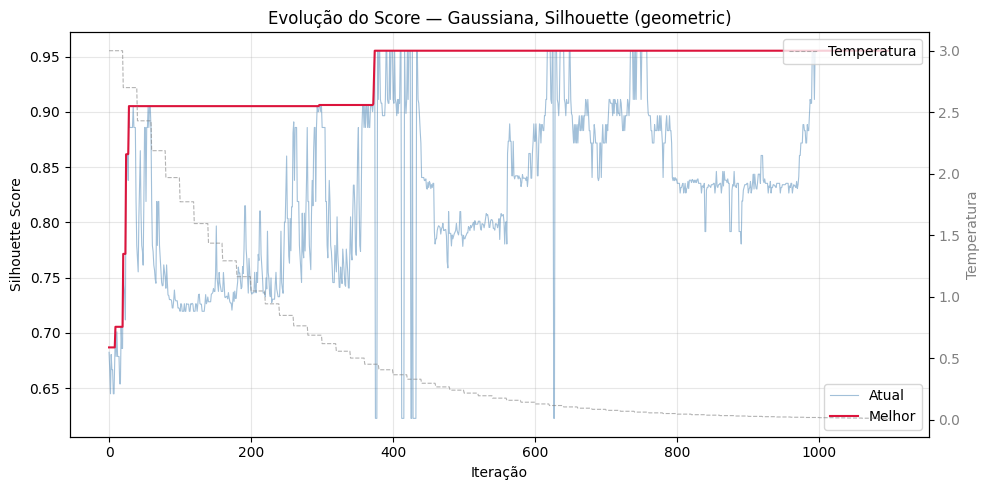

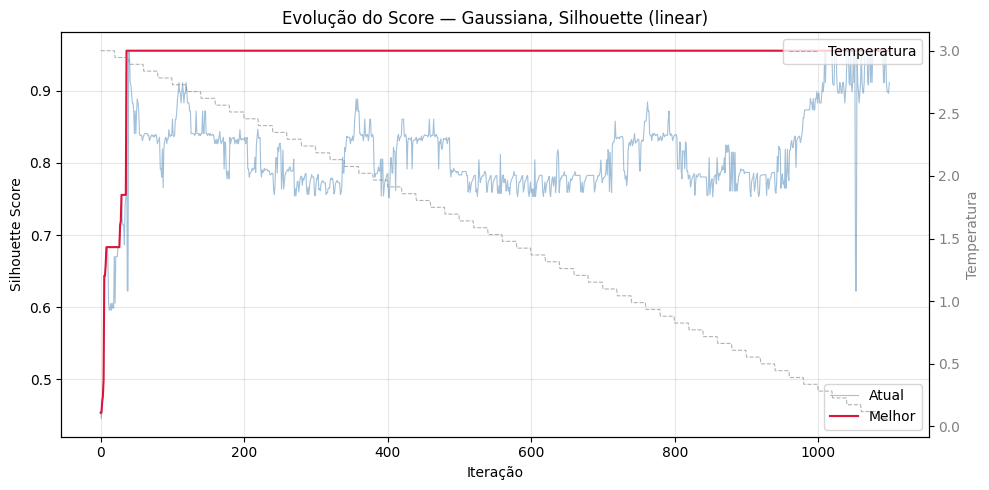

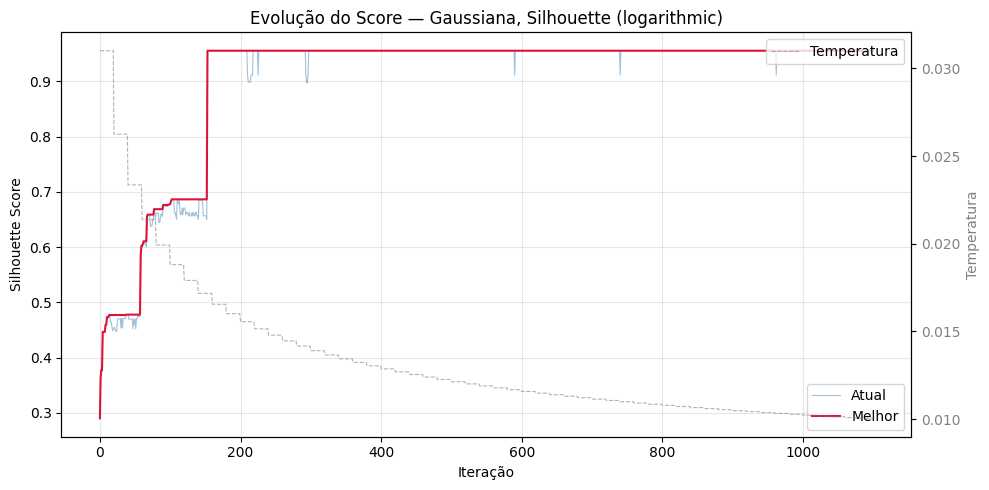

In [35]:
for schedule in COOLING_SCHEDULES:
    plot_silhouette_history(
        gauss_sil[schedule]['history'],
        title=f"Evolução do Score — Gaussiana, Silhouette ({schedule})",
        save_path=os.path.join(IMG_DIR, 'gaussian', f"gaussian_sil_history_{schedule}.png")
    )


### 8.3 Estatísticas de visita por Nº de comunidades — Gaussiana

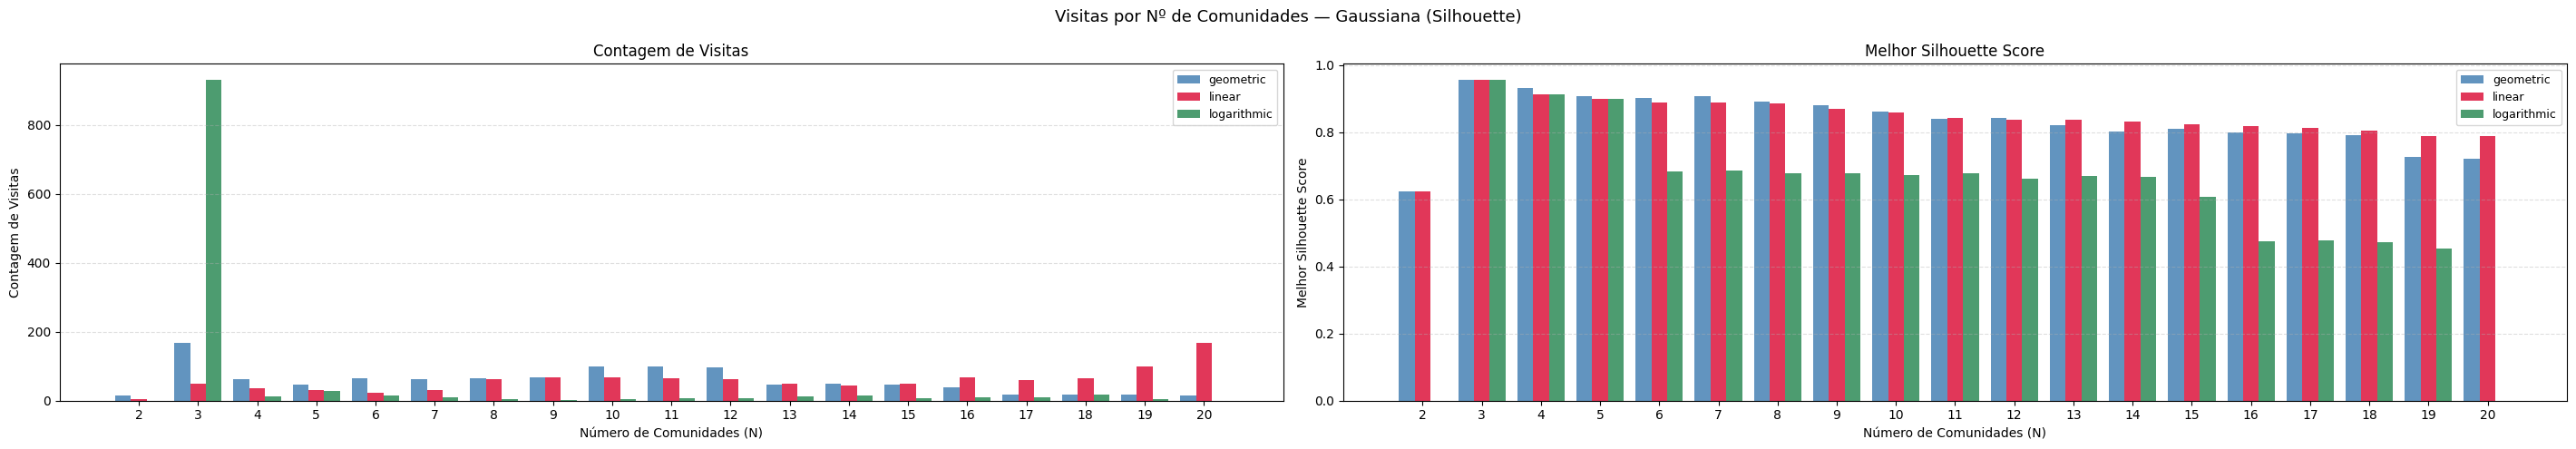

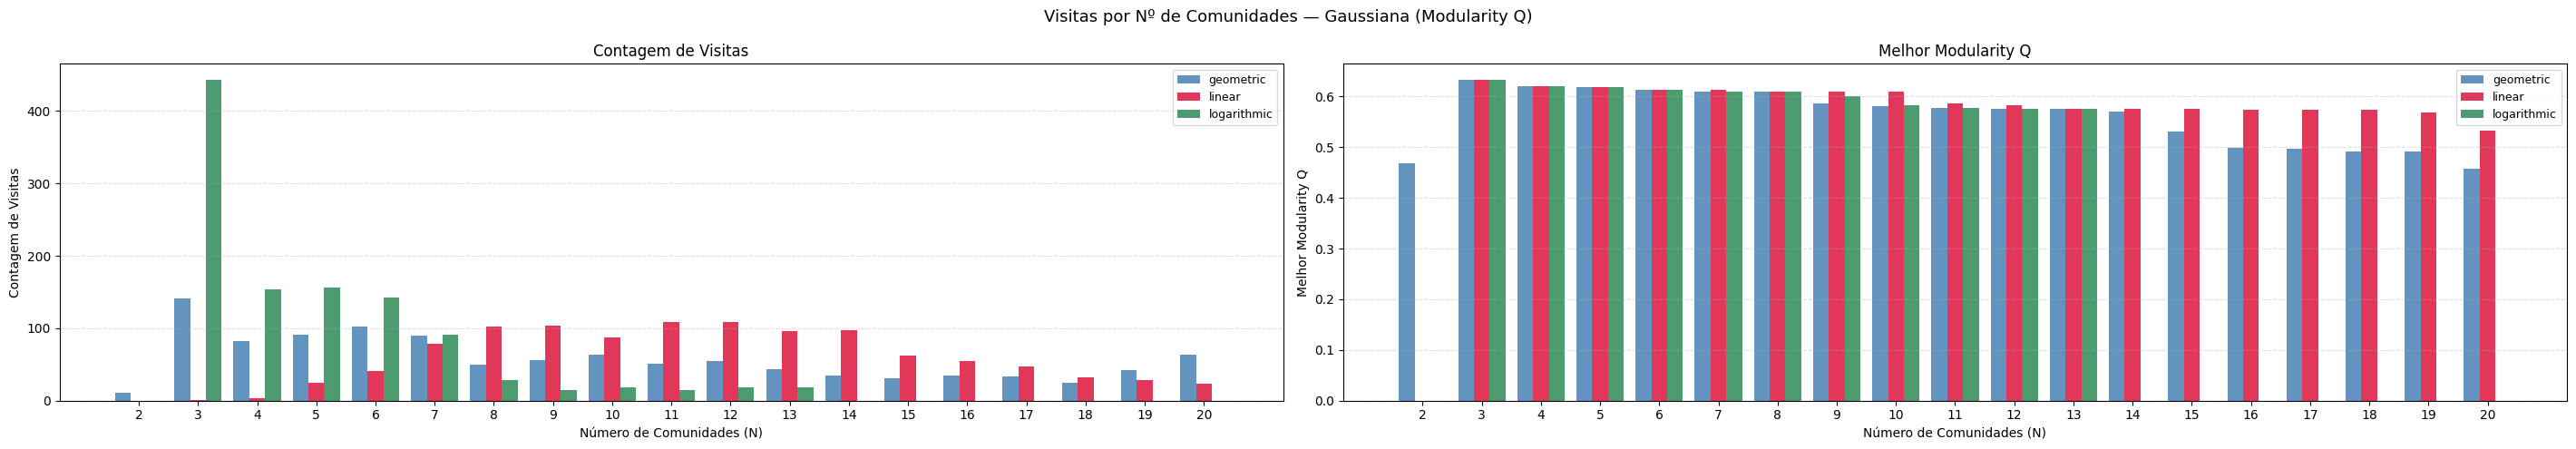

In [36]:
plot_n_communities_stats(
    histories=[gauss_sil[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Gaussiana (Silhouette)",
    score_label="Melhor Silhouette Score",
    save_path=os.path.join(IMG_DIR, 'gaussian', "gaussian_n_communities_sil.png")
)
plot_n_communities_stats(
    histories=[gauss_mod[s]['history'] for s in COOLING_SCHEDULES],
    labels=COOLING_SCHEDULES,
    title="Visitas por Nº de Comunidades — Gaussiana (Modularity Q)",
    score_label="Melhor Modularity Q",
    save_path=os.path.join(IMG_DIR, 'gaussian', "gaussian_n_communities_mod.png")
)


## 9. Comparação Final — Todos os Datasets

Tabela consolidada com o **melhor resultado** de cada otimização (Silhouette vs Modularity Q)
para os três cooling schedules em cada dataset. O melhor schedule é selecionado automaticamente.


In [37]:
dataset_labels = {
    'karate':   'Karate Club',
    'dolphins': 'Dolphins',
    'polbooks': 'Political Books',
    'lesmis':   'Les Misérables',
    'football': 'Football',
    'adhoc':    'Ad Hoc SBM',
    'gaussian': 'Gaussiana',
}

# Número real de comunidades quando conhecido
real_n_communities = {
    'karate':   2,   # Zachary: 2 facções
    'dolphins': 2,   # Lusseau et al.: 2 grupos sociais
    'polbooks': 3,   # liberal, neutro, conservador
    'lesmis':   None,
    'football': 12,  # 12 conferências NCAA
    'adhoc':    4,   # gerado com num_communities=4
    'gaussian': 3,   # gerado com 3 gaussianas
}

rows = []
for ds, ds_label in dataset_labels.items():
    if ds not in all_results:
        continue
    for obj_key, obj_label, score_col in [('sil', 'Silhouette', 'Sil.'), ('mod', 'Modularity Q', 'Q')]:
        obj_data = all_results[ds][obj_key]
        best_s = max(obj_data, key=lambda s: obj_data[s]['score'])
        r = obj_data[best_s]
        real_k = real_n_communities.get(ds)
        rows.append({
            'Dataset': ds_label,
            'Otimização': obj_label,
            'Melhor Schedule': best_s,
            'K real': real_k if real_k is not None else 'N/A',
            'K detectado': r['n_comm'],
            'Score': round(r['score'], 4),
            'ARI': round(r['ari'], 4) if r['ari'] is not None else 'N/A',
        })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))
df_summary


        Dataset   Otimização Melhor Schedule K real  K detectado  Score     ARI
    Karate Club   Silhouette       geometric      2            3 0.6615  0.6841
    Karate Club Modularity Q       geometric      2            3 0.4345  0.6841
       Dolphins   Silhouette       geometric      2            2 0.7300     N/A
       Dolphins Modularity Q       geometric      2            6 0.4864     N/A
Political Books   Silhouette       geometric      3            2 0.6491  0.6671
Political Books Modularity Q       geometric      3            5 0.5244  0.6024
 Les Misérables   Silhouette          linear    N/A           11 0.6172     N/A
 Les Misérables Modularity Q     logarithmic    N/A            8 0.5342     N/A
       Football   Silhouette       geometric     12           12 0.5737  0.8927
       Football Modularity Q       geometric     12           10 0.6005  0.7837
     Ad Hoc SBM   Silhouette          linear      4            4 0.5706     1.0
     Ad Hoc SBM Modularity Q       geome

,Dataset,Otimização,Melhor Schedule,K real,K detectado,Score,ARI
0,Karate Club,Silhouette,geometric,2,3,0.6615,0.6841
1,Karate Club,Modularity Q,geometric,2,3,0.4345,0.6841
2,Dolphins,Silhouette,geometric,2,2,0.7300,N/A
3,Dolphins,Modularity Q,geometric,2,6,0.4864,N/A
4,Political Books,Silhouette,geometric,3,2,0.6491,0.6671
5,Political Books,Modularity Q,geometric,3,5,0.5244,0.6024
6,Les Misérables,Silhouette,linear,N/A,11,0.6172,N/A
7,Les Misérables,Modularity Q,logarithmic,N/A,8,0.5342,N/A
8,Football,Silhouette,geometric,12,12,0.5737,0.8927
9,Football,Modularity Q,geometric,12,10,0.6005,0.7837


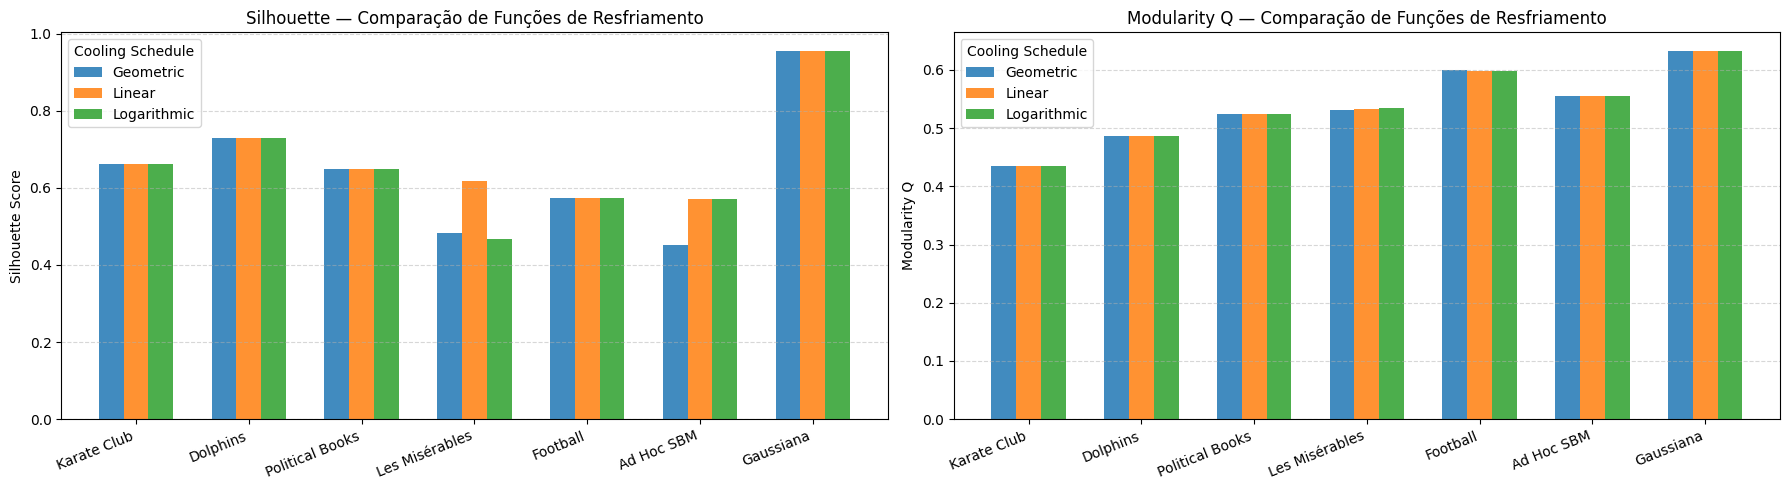

In [38]:

schedule_colors = {'geometric': '#1f77b4', 'linear': '#ff7f0e', 'logarithmic': '#2ca02c'}
all_ds = [ds for ds in dataset_labels if ds in all_results]
n_ds = len(all_ds)
n_sched = len(COOLING_SCHEDULES)
x = np.arange(n_ds)
w = 0.22  # largura de cada barra

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, obj_key, obj_label, score_label in [
    (axes[0], 'sil', 'Silhouette', 'Silhouette Score'),
    (axes[1], 'mod', 'Modularity Q', 'Modularity Q'),
]:
    for j, schedule in enumerate(COOLING_SCHEDULES):
        vals = [all_results[ds][obj_key][schedule]['score'] for ds in all_ds]
        offset = (j - (n_sched - 1) / 2) * w
        bars = ax.bar(x + offset, vals, w,
                      label=schedule.capitalize(),
                      color=schedule_colors[schedule],
                      alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([dataset_labels[ds] for ds in all_ds], rotation=22, ha='right')
    ax.set_ylabel(score_label)
    ax.set_title(f'{obj_label} — Comparação de Funções de Resfriamento')
    ax.legend(title='Cooling Schedule')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
os.makedirs(IMG_DIR, exist_ok=True)
plt.savefig(os.path.join(IMG_DIR, "cooling_schedule_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()


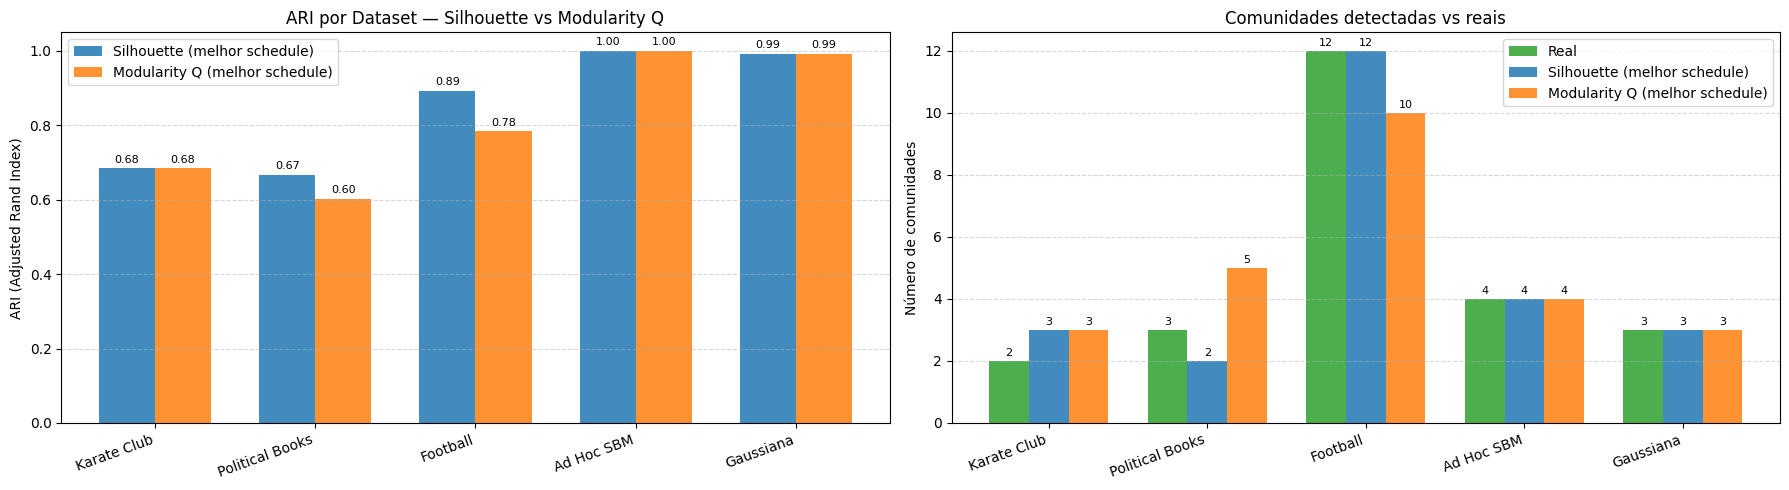

In [39]:
# Datasets com ground truth
ds_with_gt = [ds for ds in dataset_labels if ds in all_results
              and all_results[ds]['sil'][COOLING_SCHEDULES[0]]['ari'] is not None]

x = np.arange(len(ds_with_gt))

ari_sil, ari_mod = [], []
n_real, n_sil, n_mod = [], [], []

for ds in ds_with_gt:
    best_s_sil = max(COOLING_SCHEDULES, key=lambda s: all_results[ds]['sil'][s]['score'])
    best_s_mod = max(COOLING_SCHEDULES, key=lambda s: all_results[ds]['mod'][s]['score'])
    ari_sil.append(all_results[ds]['sil'][best_s_sil]['ari'])
    ari_mod.append(all_results[ds]['mod'][best_s_mod]['ari'])
    n_real.append(real_n_communities[ds])
    n_sil.append(all_results[ds]['sil'][best_s_sil]['n_comm'])
    n_mod.append(all_results[ds]['mod'][best_s_mod]['n_comm'])

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# --- ARI ---
w = 0.35
bars_sil = ax.bar(x - w/2, ari_sil, w, label='Silhouette (melhor schedule)', color='#1f77b4', alpha=0.85)
bars_mod = ax.bar(x + w/2, ari_mod, w, label='Modularity Q (melhor schedule)', color='#ff7f0e', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([dataset_labels[ds] for ds in ds_with_gt], rotation=20, ha='right')
ax.set_ylabel('ARI (Adjusted Rand Index)')
ax.set_title('ARI por Dataset — Silhouette vs Modularity Q')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar in [*bars_sil, *bars_mod]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

# --- Número de comunidades ---
w3 = 0.25
bars_real = ax2.bar(x - w3, n_real, w3, label='Real',                       color='#2ca02c', alpha=0.85)
bars_nsil = ax2.bar(x,      n_sil,  w3, label='Silhouette (melhor schedule)', color='#1f77b4', alpha=0.85)
bars_nmod = ax2.bar(x + w3, n_mod,  w3, label='Modularity Q (melhor schedule)', color='#ff7f0e', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels([dataset_labels[ds] for ds in ds_with_gt], rotation=20, ha='right')
ax2.set_ylabel('Número de comunidades')
ax2.set_title('Comunidades detectadas vs reais')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)
for bar in [*bars_real, *bars_nsil, *bars_nmod]:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "ari_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
